### 一、 多层感知机

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

1. 导入库和准备数据

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
# 加载Fashion-MNIST数据集
print("加载Fashion-MNIST数据集...")
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图片转换为Tensor，范围[0,1]
    transforms.Lambda(lambda x: x.view(-1))  # 展平为1维向量 28*28=784
])

加载Fashion-MNIST数据集...


In [4]:
# 下载训练集和测试集
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

In [5]:
# 使用部分数据加快训练（可选）
train_dataset = Subset(train_dataset, range(3000))  # 使用3000个样本
test_dataset = Subset(test_dataset, range(500))      # 使用500个测试样本

In [6]:
# 创建数据加载器
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"输入特征维度: 784 (28x28)")
print(f"输出类别数: 10")

训练集大小: 3000
测试集大小: 500
输入特征维度: 784 (28x28)
输出类别数: 10


In [8]:
# 查看一个样本
sample_img, sample_label = train_dataset[0]
print(f"\n样本形状: {sample_img.shape}")
print(f"样本标签: {sample_label}")


样本形状: torch.Size([784])
样本标签: 9


2. 初始化模型参数

In [9]:
class MLPFromScratch:
    """
    单隐藏层多层感知机
    输入层: 784个节点 (图像像素)
    隐藏层: 256个节点 (可调整)
    输出层: 10个节点 (10个类别)
    """
    def __init__(self, input_size=784, hidden_size=256, output_size=10):
        """
        初始化参数
        
        参数说明:
        - W1: 输入层到隐藏层的权重矩阵 [input_size, hidden_size]
        - b1: 隐藏层的偏置 [1, hidden_size]
        - W2: 隐藏层到输出层的权重矩阵 [hidden_size, output_size]
        - b2: 输出层的偏置 [1, output_size]
        """
        
        # 【重点解释】参数初始化
        # 使用正态分布初始化权重（均值为0，标准差为0.01）
        # 为什么要正态分布？随机初始化能打破对称性，让不同神经元学到不同特征
        # 标准差不宜太大，否则激活值容易饱和（ReLU会输出0）
        self.W1 = torch.randn(input_size, hidden_size) * 0.01
        self.b1 = torch.zeros(1, hidden_size)
        self.W2 = torch.randn(hidden_size, output_size) * 0.01
        self.b2 = torch.zeros(1, output_size)
        
        # 将参数设置为需要梯度（用于自动微分）
        # requires_grad=True让PyTorch自动计算梯度
        self.W1.requires_grad_(True)
        self.b1.requires_grad_(True)
        self.W2.requires_grad_(True)
        self.b2.requires_grad_(True)
        
        print(f"参数形状:")
        print(f"W1: {self.W1.shape} (输入→隐藏层)")
        print(f"b1: {self.b1.shape}")
        print(f"W2: {self.W2.shape} (隐藏层→输出)")
        print(f"b2: {self.b2.shape}")
        
    def relu(self, x):
        """
        【重点解释】ReLU激活函数
        ReLU(x) = max(0, x)
        
        作用：引入非线性，让神经网络能学习复杂模式
        优点：计算简单，缓解梯度消失问题
        缺点：负值区域梯度为0，可能导致"神经元死亡"
        """
        return torch.maximum(torch.tensor(0.0), x)
    
    def forward(self, x):
        """
        前向传播
        
        【重点解释】神经网络计算过程:
        1. 输入层 → 隐藏层: z1 = x @ W1 + b1
        2. ReLU激活: a1 = ReLU(z1)
        3. 隐藏层 → 输出层: z2 = a1 @ W2 + b2
        """
        # x: [batch_size, input_size]
        
        # 第一层线性变换: z1 = xW1 + b1
        # @ 是矩阵乘法运算符，等价于 torch.matmul
        z1 = x @ self.W1 + self.b1  # [batch_size, hidden_size]
        
        # ReLU激活
        a1 = self.relu(z1)  # [batch_size, hidden_size]
        
        # 第二层线性变换: z2 = a1W2 + b2
        z2 = a1 @ self.W2 + self.b2  # [batch_size, output_size]
        
        return z2, a1  # 返回logits和隐藏层激活值
    
    def softmax_cross_entropy(self, logits, y_true):
        """
        【重点解释】Softmax + 交叉熵损失
        
        Softmax函数: 将logits转换为概率分布
        p_k = exp(z_k) / sum(exp(z_j))
        
        交叉熵损失: -log(p_correct) 
        其中 p_correct 是正确类别的预测概率
        
        数学上合并实现更稳定: 
        loss = -log(exp(z_correct) / sum(exp(z_j))) 
             = -z_correct + log(sum(exp(z_j)))
        """
        batch_size = logits.shape[0]
        
        # 数值稳定版本：减去最大值防止exp溢出
        # 这是 Softmax 的常用技巧
        logits_max = logits.max(dim=1, keepdim=True)[0]
        logits_stable = logits - logits_max
        
        # 计算exp和sum
        exp_logits = torch.exp(logits_stable)
        sum_exp = exp_logits.sum(dim=1, keepdim=True)
        
        # Softmax概率
        probs = exp_logits / sum_exp  # [batch_size, output_size]
        
        # 提取正确类别的概率
        # y_true是索引，例如[2, 5, 0, ...]，表示每个样本的真实类别
        correct_probs = probs[range(batch_size), y_true]
        
        # 交叉熵损失 = -log(正确类别的概率)
        # 加一个小数防止log(0)
        loss = -torch.log(correct_probs + 1e-8)
        
        # 返回平均损失
        return loss.mean()
    
    def compute_accuracy(self, logits, y_true):
        """
        计算准确率
        """
        predictions = torch.argmax(logits, dim=1)  # 取概率最大的类别
        correct = (predictions == y_true).sum().item()
        accuracy = correct / len(y_true)
        return accuracy

3. 训练函数

In [10]:
def train_model(model, train_loader, learning_rate=0.01, epochs=10):
    """
    训练模型
    
    【重点解释】梯度下降更新参数:
    1. 前向传播计算损失
    2. 反向传播计算梯度 (loss对每个参数的导数)
    3. 参数更新: 参数 = 参数 - 学习率 × 梯度
    
    为什么减去梯度？梯度指向损失增加最快的方向，减去它让损失下降
    """
    
    print("\n开始训练...")
    print("="*50)
    
    for epoch in range(epochs):
        total_loss = 0
        total_acc = 0
        num_batches = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            # 前向传播
            logits, _ = model.forward(images)
            
            # 计算损失
            loss = model.softmax_cross_entropy(logits, labels)
            
            # 【重点解释】反向传播: 自动计算梯度
            # PyTorch会计算loss对requires_grad=True的参数的梯度
            # 梯度存储在参数的.grad属性中
            loss.backward()
            
            # 【重点解释】更新参数 (SGD)
            # 使用梯度下降更新参数
            with torch.no_grad():  # 不需要记录梯度
                model.W1 -= learning_rate * model.W1.grad
                model.b1 -= learning_rate * model.b1.grad
                model.W2 -= learning_rate * model.W2.grad
                model.b2 -= learning_rate * model.b2.grad
            
            # 【重要】清空梯度，否则下次会累加
            # 必须做！否则梯度会不断累积
            model.W1.grad.zero_()
            model.b1.grad.zero_()
            model.W2.grad.zero_()
            model.b2.grad.zero_()
            
            # 计算准确率
            acc = model.compute_accuracy(logits, labels)
            
            total_loss += loss.item()
            total_acc += acc
            num_batches += 1
            
            # 打印进度
            if batch_idx % 20 == 0:
                print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx:3d} | "
                      f"Loss: {loss.item():.4f} | Acc: {acc:.2%}")
        
        avg_loss = total_loss / num_batches
        avg_acc = total_acc / num_batches
        print(f"{'='*50}")
        print(f"Epoch {epoch+1}/{epochs} 平均 | Loss: {avg_loss:.4f} | Acc: {avg_acc:.2%}")
        print(f"{'='*50}\n")

# 初始化模型
model = MLPFromScratch(input_size=784, hidden_size=256, output_size=10)

# 训练模型
train_model(model, train_loader, learning_rate=0.01, epochs=5)

参数形状:
W1: torch.Size([784, 256]) (输入→隐藏层)
b1: torch.Size([1, 256])
W2: torch.Size([256, 10]) (隐藏层→输出)
b2: torch.Size([1, 10])

开始训练...
Epoch 1/5 | Batch   0 | Loss: 2.3053 | Acc: 15.62%
Epoch 1/5 | Batch  20 | Loss: 2.2899 | Acc: 25.00%
Epoch 1/5 | Batch  40 | Loss: 2.2780 | Acc: 25.00%
Epoch 1/5 平均 | Loss: 2.2875 | Acc: 23.35%

Epoch 2/5 | Batch   0 | Loss: 2.2702 | Acc: 28.12%
Epoch 2/5 | Batch  20 | Loss: 2.2443 | Acc: 43.75%
Epoch 2/5 | Batch  40 | Loss: 2.2439 | Acc: 25.00%
Epoch 2/5 平均 | Loss: 2.2481 | Acc: 31.97%

Epoch 3/5 | Batch   0 | Loss: 2.2060 | Acc: 40.62%
Epoch 3/5 | Batch  20 | Loss: 2.1987 | Acc: 25.00%
Epoch 3/5 | Batch  40 | Loss: 2.1443 | Acc: 40.62%
Epoch 3/5 平均 | Loss: 2.1815 | Acc: 38.50%

Epoch 4/5 | Batch   0 | Loss: 2.1161 | Acc: 42.19%
Epoch 4/5 | Batch  20 | Loss: 2.0800 | Acc: 37.50%
Epoch 4/5 | Batch  40 | Loss: 2.0543 | Acc: 48.44%
Epoch 4/5 平均 | Loss: 2.0728 | Acc: 41.23%

Epoch 5/5 | Batch   0 | Loss: 2.0091 | Acc: 42.19%
Epoch 5/5 | Batch  20 | Loss: 

4. 测试模型

In [11]:
def test_model(model, test_loader):
    """
    在测试集上评估模型
    """
    print("\n测试模型...")
    print("="*50)
    
    total_correct = 0
    total_samples = 0
    total_loss = 0
    
    # 类别名称 (Fashion-MNIST的10个类别)
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    with torch.no_grad():  # 测试时不需要计算梯度
        for images, labels in test_loader:
            logits, _ = model.forward(images)
            loss = model.softmax_cross_entropy(logits, labels)
            
            predictions = torch.argmax(logits, dim=1)
            correct = (predictions == labels).sum().item()
            
            total_correct += correct
            total_samples += len(labels)
            total_loss += loss.item()
    
    accuracy = total_correct / total_samples
    avg_loss = total_loss / len(test_loader)
    
    print(f"测试集结果:")
    print(f"平均损失: {avg_loss:.4f}")
    print(f"准确率: {accuracy:.2%} ({total_correct}/{total_samples})")
    print("="*50)
    
    return accuracy

# 测试模型
test_accuracy = test_model(model, test_loader)


测试模型...
测试集结果:
平均损失: 1.8254
准确率: 46.60% (233/500)


5. 可视化结果

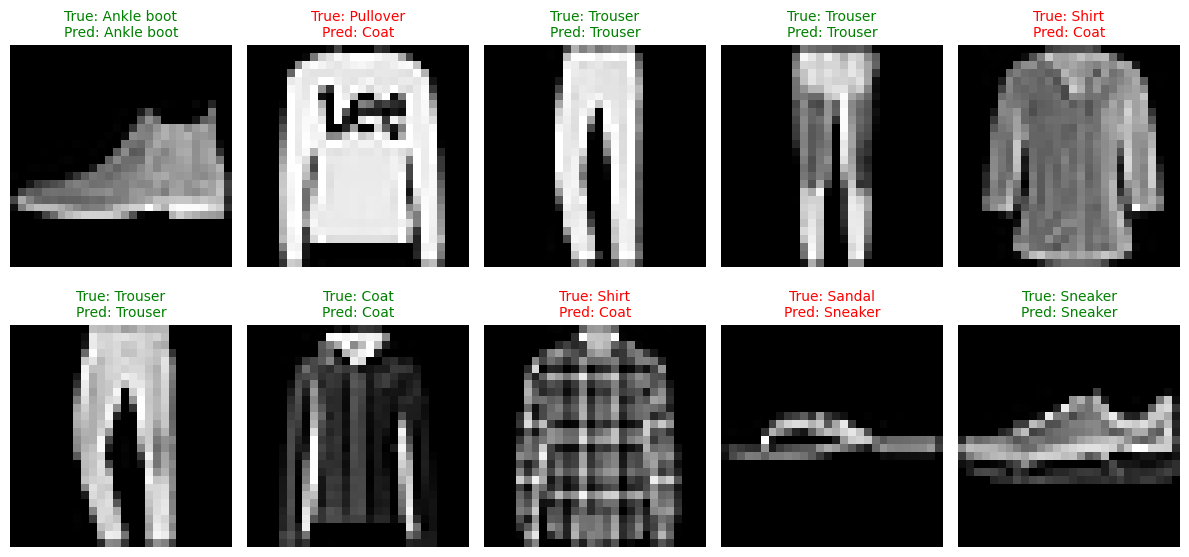

In [12]:
def visualize_predictions(model, test_loader, num_images=10):
    """
    可视化模型的预测结果
    """
    # 类别名称
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    # 获取一批测试数据
    images, labels = next(iter(test_loader))
    
    with torch.no_grad():
        logits, _ = model.forward(images)
        predictions = torch.argmax(logits, dim=1)
    
    # 显示图片
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.ravel()
    
    for i in range(min(num_images, len(images))):
        # 将图像从784维重塑为28x28
        img = images[i].reshape(28, 28).numpy()
        
        axes[i].imshow(img, cmap='gray')
        axes[i].axis('off')
        
        true_label = class_names[labels[i]]
        pred_label = class_names[predictions[i]]
        color = 'green' if labels[i] == predictions[i] else 'red'
        
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', 
                          color=color, fontsize=10)
    
    plt.tight_layout()
    plt.show()

# 可视化预测结果
visualize_predictions(model, test_loader)

### 二、模型选择，权重衰减和丢弃法

In [13]:
class MLPWithRegularization:
    """
    带L2正则化和Dropout的单隐藏层MLP
    """
    def __init__(self, input_size=784, hidden_size=256, output_size=10, 
                 dropout_rate=0.5):
        """
        初始化参数
        
        参数:
        - dropout_rate: Dropout概率，即神经元被丢弃的概率
        """
        # 参数初始化（和之前一样）
        self.W1 = torch.randn(input_size, hidden_size) * 0.01
        self.b1 = torch.zeros(1, hidden_size)
        self.W2 = torch.randn(hidden_size, output_size) * 0.01
        self.b2 = torch.zeros(1, output_size)
        
        self.W1.requires_grad_(True)
        self.b1.requires_grad_(True)
        self.W2.requires_grad_(True)
        self.b2.requires_grad_(True)
        
        self.dropout_rate = dropout_rate
        self.training = True  # 默认为训练模式
        
    def relu(self, x):
        """ReLU激活函数"""
        return torch.maximum(torch.tensor(0.0), x)
    
    def dropout_layer(self, X, dropout_rate):
        """
        【重点解释】从零实现Dropout
        
        Dropout原理：
        1. 训练时，以概率p随机将神经元输出置为0
        2. 为了防止激活值期望变化，需要将保留的神经元放大 1/(1-p) 倍
        3. 测试时，不使用Dropout，保持所有神经元
        
        为什么有效？
        - 防止神经元之间产生复杂的共适应关系
        - 相当于训练了多个子网络的集成
        - 增强模型的泛化能力
        
        数学公式：
        mask ~ Bernoulli(1-p)  # 以概率(1-p)保留
        output = (mask * X) / (1-p)  # 缩放保持期望不变
        """
        if not self.training or dropout_rate == 0:
            # 测试模式或p=0时，直接返回原输入
            return X
        
        # 生成随机掩码（Mask）
        # 以概率 (1-dropout_rate) 保留，以概率 dropout_rate 置0
        keep_prob = 1 - dropout_rate
        # 生成与X形状相同的伯努利分布掩码
        mask = torch.rand(X.shape) < keep_prob
        mask = mask.float()  # 转换为0/1
        
        # 应用掩码并缩放
        # 除以keep_prob是为了保持激活值的期望不变
        # 证明：E[mask * X / keep_prob] = (keep_prob * X) / keep_prob = X
        output = X * mask / keep_prob
        
        return output
    
    def forward(self, x):
        """
        前向传播（包含Dropout）
        """
        # 第一层：线性变换
        z1 = x @ self.W1 + self.b1
        # ReLU激活
        a1 = self.relu(z1)
        # 应用Dropout（只在训练时）
        a1_dropped = self.dropout_layer(a1, self.dropout_rate)
        
        # 第二层：线性变换
        z2 = a1_dropped @ self.W2 + self.b2
        
        return z2, a1_dropped
    
    def softmax_cross_entropy(self, logits, y_true):
        """Softmax交叉熵损失（与之前相同）"""
        batch_size = logits.shape[0]
        
        # 数值稳定版本
        logits_max = logits.max(dim=1, keepdim=True)[0]
        logits_stable = logits - logits_max
        
        exp_logits = torch.exp(logits_stable)
        sum_exp = exp_logits.sum(dim=1, keepdim=True)
        probs = exp_logits / sum_exp
        
        correct_probs = probs[range(batch_size), y_true]
        loss = -torch.log(correct_probs + 1e-8)
        
        return loss.mean()
    
    def compute_accuracy(self, logits, y_true):
        """计算准确率"""
        predictions = torch.argmax(logits, dim=1)
        correct = (predictions == y_true).sum().item()
        return correct / len(y_true)
    
    def compute_l2_loss(self, weight_decay):
        """
        【重点解释】L2正则化损失
        
        L2正则化原理：
        - 在原始损失上加上权重平方和的惩罚项
        - 总损失 = 原始损失 + λ * (||W1||² + ||W2||²)
        
        为什么有效？
        - 惩罚大的权重，使权重趋向于较小的值
        - 防止模型对某些特征过度敏感
        - 提高模型的泛化能力
        
        在SGD中实现为：W = (1 - ηλ)W - η∂L/∂W
        """
        l2_loss = (self.W1 ** 2).sum() + (self.W2 ** 2).sum()
        return weight_decay * l2_loss
    
    def train_mode(self):
        """设置为训练模式"""
        self.training = True
    
    def eval_mode(self):
        """设置为测试模式"""
        self.training = False


def train_with_regularization(model, train_loader, test_loader, 
                            learning_rate=0.01, epochs=50, 
                            weight_decay=0.0, dropout_rate=0.0,
                            model_name="Model"):
    """
    训练带正则化的模型
    
    参数:
    - weight_decay: L2正则化系数（λ）
    - dropout_rate: Dropout概率
    """
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    print(f"\n训练 {model_name}...")
    print(f"配置: learning_rate={learning_rate}, weight_decay={weight_decay}, dropout={dropout_rate}")
    print("="*60)
    
    for epoch in range(epochs):
        # 训练阶段
        model.train_mode()
        total_train_loss = 0
        total_train_acc = 0
        num_batches = 0
        
        for images, labels in train_loader:
            # 前向传播
            logits, _ = model.forward(images)
            
            # 计算原始损失
            original_loss = model.softmax_cross_entropy(logits, labels)
            
            # 添加L2正则化损失
            l2_loss = model.compute_l2_loss(weight_decay)
            total_loss = original_loss + l2_loss
            
            # 反向传播
            total_loss.backward()
            
            # 【重点解释】带权重衰减的参数更新
            # 标准公式: W_new = W_old - η * (∂L/∂W + 2λW)
            # 等价形式: W_new = (1 - 2ηλ)W_old - η * ∂L/∂W
            # 这里我们使用第一种形式更清晰
            with torch.no_grad():
                # 权重衰减项（L2正则化梯度）
                model.W1 -= learning_rate * (model.W1.grad + 2 * weight_decay * model.W1)
                model.b1 -= learning_rate * model.b1.grad
                model.W2 -= learning_rate * (model.W2.grad + 2 * weight_decay * model.W2)
                model.b2 -= learning_rate * model.b2.grad
            
            # 清空梯度
            model.W1.grad.zero_()
            model.b1.grad.zero_()
            model.W2.grad.zero_()
            model.b2.grad.zero_()
            
            # 计算准确率
            acc = model.compute_accuracy(logits, labels)
            
            total_train_loss += original_loss.item()
            total_train_acc += acc
            num_batches += 1
        
        avg_train_loss = total_train_loss / num_batches
        avg_train_acc = total_train_acc / num_batches
        train_losses.append(avg_train_loss)
        train_accs.append(avg_train_acc)
        
        # 测试阶段
        model.eval_mode()
        total_test_loss = 0
        total_test_acc = 0
        num_test_batches = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                logits, _ = model.forward(images)
                loss = model.softmax_cross_entropy(logits, labels)
                acc = model.compute_accuracy(logits, labels)
                
                total_test_loss += loss.item()
                total_test_acc += acc
                num_test_batches += 1
        
        avg_test_loss = total_test_loss / num_test_batches
        avg_test_acc = total_test_acc / num_test_batches
        test_losses.append(avg_test_loss)
        test_accs.append(avg_test_acc)
        
        # 打印进度
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2%} | "
                  f"Test Loss: {avg_test_loss:.4f} | Test Acc: {avg_test_acc:.2%}")
    
    print(f"{model_name} 训练完成")
    print("="*60)
    
    return train_losses, test_losses, train_accs, test_accs

In [14]:
def create_overfitting_scenario():
    """
    创建一个容易过拟合的场景：
    1. 使用非常少的训练样本（500个）
    2. 使用较大的隐藏层（512个神经元）
    3. 训练多个epochs
    """
    print("准备过拟合实验数据...")
    
    # 加载完整数据集
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])
    
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data', train=False, download=True, transform=transform
    )
    
    # 关键：只使用极少的训练样本（500个）来制造过拟合
    train_subset = Subset(train_dataset, range(500))
    test_subset = Subset(test_dataset, range(1000))
    
    # 使用较小的batch_size
    batch_size = 32
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)
    
    print(f"训练集样本数: {len(train_subset)} (故意使用很少的数据)")
    print(f"测试集样本数: {len(test_subset)}")
    print(f"输入维度: 784")
    print(f"隐藏层: 512 (较大，增强过拟合)")
    print(f"输出维度: 10")
    
    return train_loader, test_loader

In [15]:
# 创建过拟合场景
train_loader, test_loader = create_overfitting_scenario()

# 实验配置
epochs = 100  # 训练更多轮次，让过拟合更明显
learning_rate = 0.01

# 存储所有结果
results = {}

# 实验1: 无正则化（Baseline）
print("\n" + "="*70)
print("实验1: 无正则化 - 预期会严重过拟合")
print("="*70)
model_baseline = MLPWithRegularization(
    input_size=784, hidden_size=512, output_size=10, dropout_rate=0.0
)
train_losses1, test_losses1, train_accs1, test_accs1 = train_with_regularization(
    model_baseline, train_loader, test_loader, 
    learning_rate=learning_rate, epochs=epochs,
    weight_decay=0.0, dropout_rate=0.0,
    model_name="无正则化"
)
results['baseline'] = (train_losses1, test_losses1, train_accs1, test_accs1)

# 实验2: L2正则化（权重衰减）
print("\n" + "="*70)
print("实验2: L2正则化 (λ=0.01) - 应该减轻过拟合")
print("="*70)
model_l2 = MLPWithRegularization(
    input_size=784, hidden_size=512, output_size=10, dropout_rate=0.0
)
train_losses2, test_losses2, train_accs2, test_accs2 = train_with_regularization(
    model_l2, train_loader, test_loader,
    learning_rate=learning_rate, epochs=epochs,
    weight_decay=0.01, dropout_rate=0.0,
    model_name="L2正则化 (λ=0.01)"
)
results['l2'] = (train_losses2, test_losses2, train_accs2, test_accs2)

# 实验3: Dropout
print("\n" + "="*70)
print("实验3: Dropout (p=0.5) - 应该减轻过拟合")
print("="*70)
model_dropout = MLPWithRegularization(
    input_size=784, hidden_size=512, output_size=10, dropout_rate=0.5
)
train_losses3, test_losses3, train_accs3, test_accs3 = train_with_regularization(
    model_dropout, train_loader, test_loader,
    learning_rate=learning_rate, epochs=epochs,
    weight_decay=0.0, dropout_rate=0.5,
    model_name="Dropout (p=0.5)"
)
results['dropout'] = (train_losses3, test_losses3, train_accs3, test_accs3)

# 实验4: L2 + Dropout 组合
print("\n" + "="*70)
print("实验4: L2正则化 + Dropout 组合 - 应该效果最好")
print("="*70)
model_combined = MLPWithRegularization(
    input_size=784, hidden_size=512, output_size=10, dropout_rate=0.5
)
train_losses4, test_losses4, train_accs4, test_accs4 = train_with_regularization(
    model_combined, train_loader, test_loader,
    learning_rate=learning_rate, epochs=epochs,
    weight_decay=0.01, dropout_rate=0.5,
    model_name="L2 + Dropout 组合"
)
results['combined'] = (train_losses4, test_losses4, train_accs4, test_accs4)

准备过拟合实验数据...
训练集样本数: 500 (故意使用很少的数据)
测试集样本数: 1000
输入维度: 784
隐藏层: 512 (较大，增强过拟合)
输出维度: 10

实验1: 无正则化 - 预期会严重过拟合

训练 无正则化...
配置: learning_rate=0.01, weight_decay=0.0, dropout=0.0
Epoch   5/100 | Train Loss: 2.2011 | Train Acc: 32.54% | Test Loss: 2.1812 | Test Acc: 35.16%
Epoch  10/100 | Train Loss: 1.9924 | Train Acc: 50.70% | Test Loss: 1.9598 | Test Acc: 50.10%
Epoch  15/100 | Train Loss: 1.7056 | Train Acc: 53.83% | Test Loss: 1.6700 | Test Acc: 57.32%
Epoch  20/100 | Train Loss: 1.4496 | Train Acc: 59.69% | Test Loss: 1.4278 | Test Acc: 60.16%
Epoch  25/100 | Train Loss: 1.2658 | Train Acc: 64.38% | Test Loss: 1.2556 | Test Acc: 60.74%
Epoch  30/100 | Train Loss: 1.1390 | Train Acc: 66.64% | Test Loss: 1.1346 | Test Acc: 63.48%
Epoch  35/100 | Train Loss: 1.0256 | Train Acc: 67.70% | Test Loss: 1.0390 | Test Acc: 63.96%
Epoch  40/100 | Train Loss: 0.9497 | Train Acc: 71.17% | Test Loss: 0.9692 | Test Acc: 66.70%
Epoch  45/100 | Train Loss: 0.8875 | Train Acc: 71.60% | Test Loss: 0.9

C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:47: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:47: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:47: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:47: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:47: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:47: UserWarning: Glyph 32447 (\

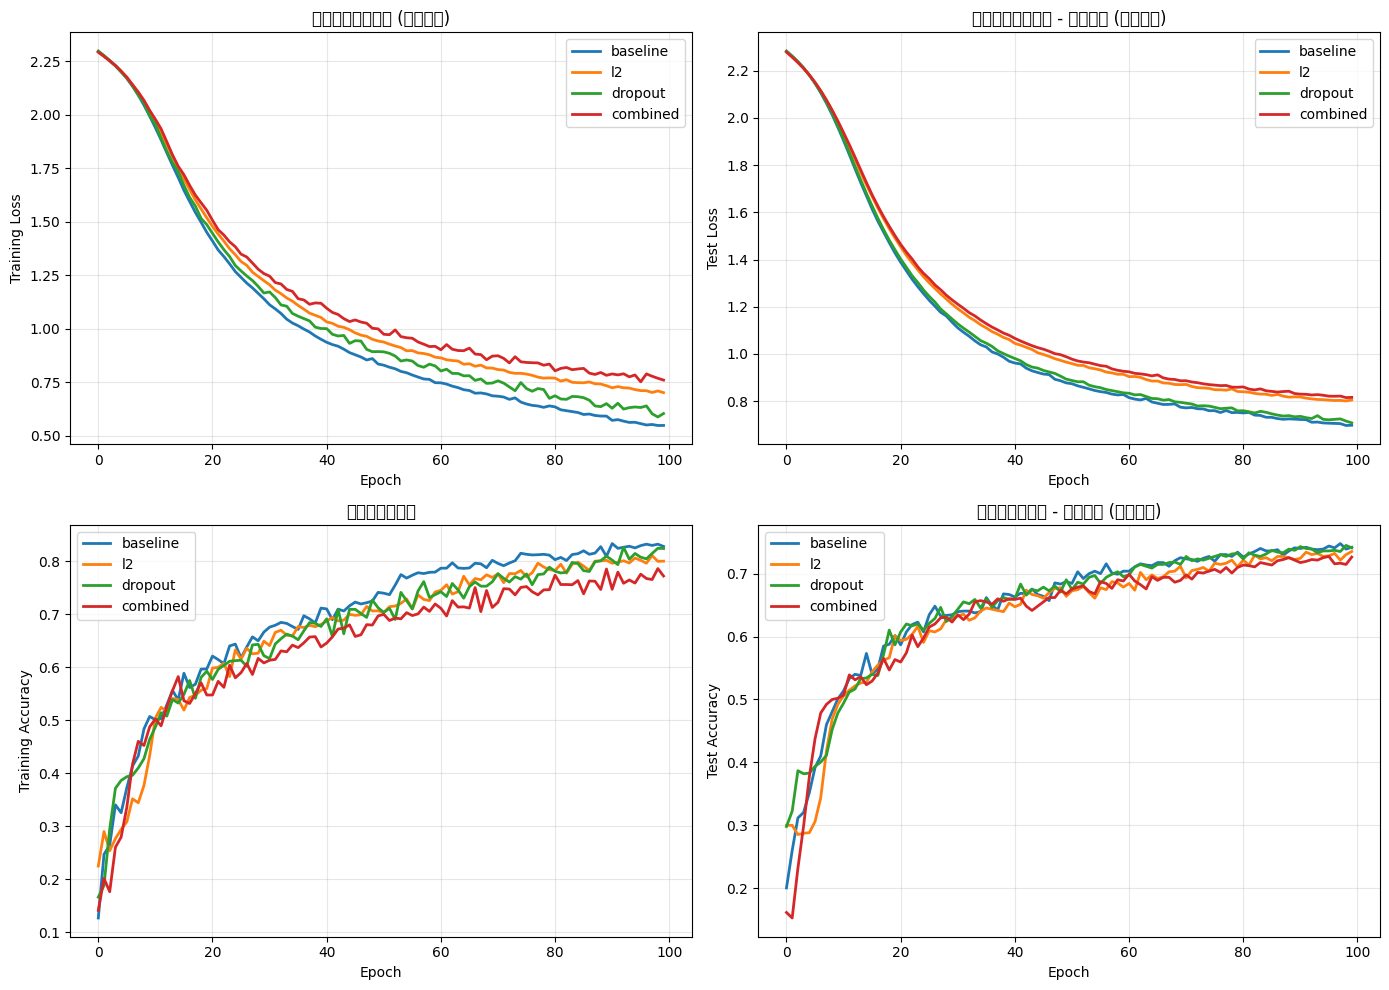

C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:65: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:65: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:65: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:65: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:65: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3848080146.py:65: UserWarning: Glyph 20998 (\

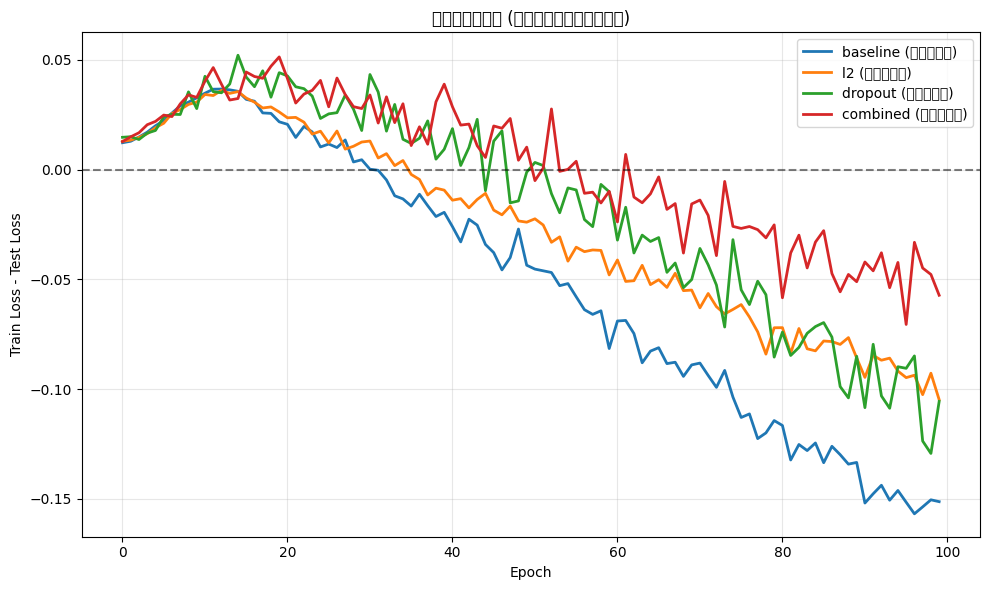


最终结果对比（最后5个epoch的平均值）

baseline:
  训练损失: 0.5500
  测试损失: 0.7027
  训练准确率: 83.05%
  测试准确率: 74.30%
  过拟合程度: -0.1527

l2:
  训练损失: 0.7057
  测试损失: 0.8034
  训练准确率: 80.20%
  测试准确率: 72.97%
  过拟合程度: -0.0977

dropout:
  训练损失: 0.6120
  测试损失: 0.7188
  训练准确率: 81.52%
  测试准确率: 73.91%
  过拟合程度: -0.1068

combined:
  训练损失: 0.7684
  测试损失: 0.8191
  训练准确率: 77.35%
  测试准确率: 72.03%
  过拟合程度: -0.0507

结论分析:
✓ 测试准确率最高的模型: baseline (74.30%)
✓ 测试损失最低的模型: baseline (0.7027)

正则化效果总结:
- 无正则化: 训练集表现好但测试集差 → 严重过拟合
- L2正则化: 通过惩罚大权重减轻过拟合
- Dropout: 通过随机丢弃神经元提高泛化能力
- 组合使用: 通常效果最好，结合两种方法的优点


In [16]:
def plot_comparison_results(results):
    """
    绘制四种方法的对比图
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. 训练损失曲线对比
    ax1 = axes[0, 0]
    for name, (train_losses, _, _, _) in results.items():
        ax1.plot(train_losses, label=name, linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Training Loss')
    ax1.set_title('训练损失曲线对比 (越低越好)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. 测试损失曲线对比（最重要！）
    ax2 = axes[0, 1]
    for name, (_, test_losses, _, _) in results.items():
        ax2.plot(test_losses, label=name, linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Test Loss')
    ax2.set_title('测试损失曲线对比 - 核心指标 (越低越好)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. 训练准确率对比
    ax3 = axes[1, 0]
    for name, (_, _, train_accs, _) in results.items():
        ax3.plot(train_accs, label=name, linewidth=2)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Training Accuracy')
    ax3.set_title('训练准确率对比')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. 测试准确率对比（最重要！）
    ax4 = axes[1, 1]
    for name, (_, _, _, test_accs) in results.items():
        ax4.plot(test_accs, label=name, linewidth=2)
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Test Accuracy')
    ax4.set_title('测试准确率对比 - 核心指标 (越高越好)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 额外绘制过拟合程度分析
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 计算训练-测试损失差距（过拟合程度）
    for name, (train_losses, test_losses, _, _) in results.items():
        gap = [t_tr - t_te for t_tr, t_te in zip(train_losses, test_losses)]
        ax.plot(gap, label=f"{name} (过拟合程度)", linewidth=2)
    
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss - Test Loss')
    ax.set_title('过拟合程度分析 (正值为过拟合，越小越好)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def print_final_comparison(results):
    """
    打印最终结果的数值对比
    """
    print("\n" + "="*80)
    print("最终结果对比（最后5个epoch的平均值）")
    print("="*80)
    
    final_results = {}
    for name, (train_losses, test_losses, train_accs, test_accs) in results.items():
        # 取最后5个epoch的平均值
        last_n = min(5, len(test_losses))
        final_train_loss = np.mean(train_losses[-last_n:])
        final_test_loss = np.mean(test_losses[-last_n:])
        final_train_acc = np.mean(train_accs[-last_n:])
        final_test_acc = np.mean(test_accs[-last_n:])
        
        final_results[name] = {
            'train_loss': final_train_loss,
            'test_loss': final_test_loss,
            'train_acc': final_train_acc,
            'test_acc': final_test_acc,
            'overfitting_gap': final_train_loss - final_test_loss
        }
        
        print(f"\n{name}:")
        print(f"  训练损失: {final_train_loss:.4f}")
        print(f"  测试损失: {final_test_loss:.4f}")
        print(f"  训练准确率: {final_train_acc:.2%}")
        print(f"  测试准确率: {final_test_acc:.2%}")
        print(f"  过拟合程度: {final_train_loss - final_test_loss:.4f}")
    
    # 找出最佳模型
    best_test_acc = max(final_results.items(), key=lambda x: x[1]['test_acc'])
    best_test_loss = min(final_results.items(), key=lambda x: x[1]['test_loss'])
    
    print("\n" + "="*80)
    print("结论分析:")
    print("="*80)
    print(f"✓ 测试准确率最高的模型: {best_test_acc[0]} ({best_test_acc[1]['test_acc']:.2%})")
    print(f"✓ 测试损失最低的模型: {best_test_loss[0]} ({best_test_loss[1]['test_loss']:.4f})")
    print("\n正则化效果总结:")
    print("- 无正则化: 训练集表现好但测试集差 → 严重过拟合")
    print("- L2正则化: 通过惩罚大权重减轻过拟合")
    print("- Dropout: 通过随机丢弃神经元提高泛化能力")
    print("- 组合使用: 通常效果最好，结合两种方法的优点")

# 绘制对比图
plot_comparison_results(results)

# 打印最终结果
print_final_comparison(results)

C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3150863518.py:29: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3150863518.py:29: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3150863518.py:29: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3150863518.py:29: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3150863518.py:29: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3150863518.py:29: UserWarning: Glyph 21069 (\

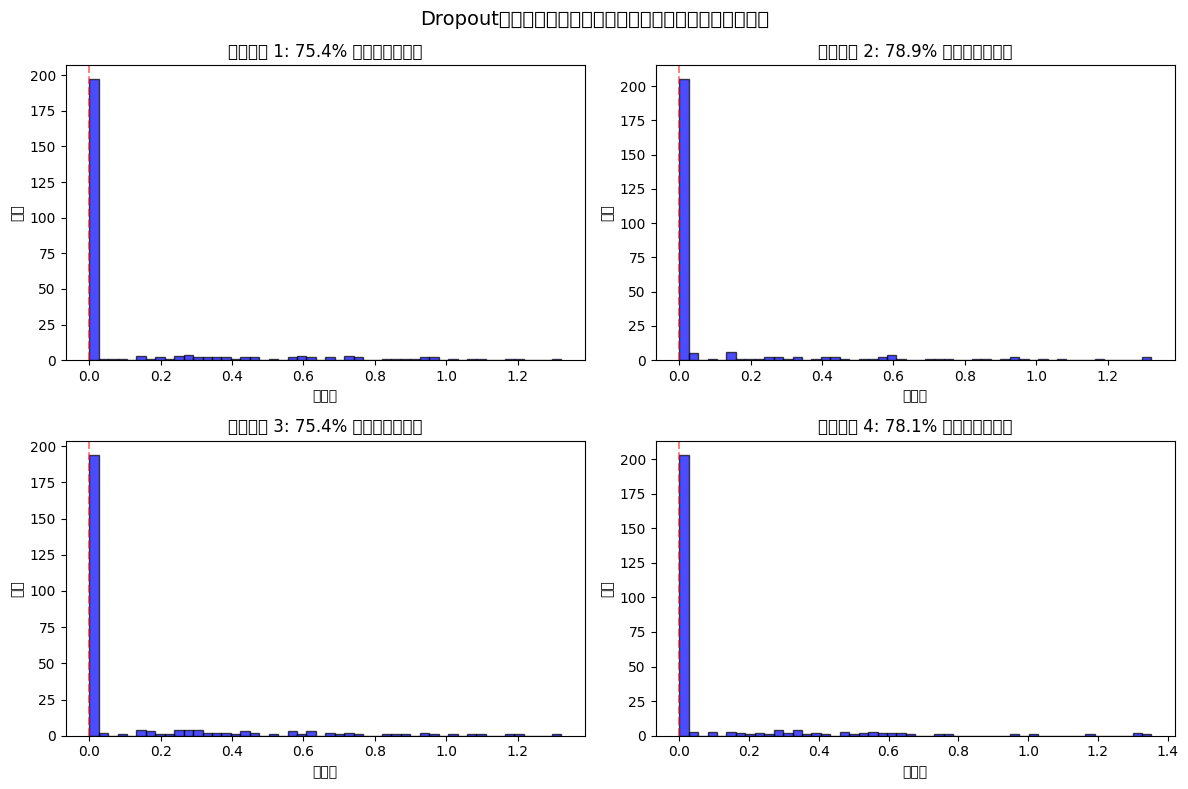

In [17]:
def visualize_dropout_effect():
    """
    直观展示Dropout的效果
    """
    # 创建一个简单的模型
    model = MLPWithRegularization(hidden_size=256, dropout_rate=0.5)
    model.train_mode()
    
    # 创建一个测试输入
    x = torch.randn(1, 784)
    
    # 多次前向传播，观察隐藏层激活值
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    for i, ax in enumerate(axes.flat):
        # 不同次数的前向传播
        _, hidden = model.forward(x)
        hidden_np = hidden.detach().numpy().flatten()
        
        # 绘制直方图
        ax.hist(hidden_np, bins=50, alpha=0.7, color='blue', edgecolor='black')
        zero_ratio = (hidden_np == 0).mean()
        ax.set_title(f'前向传播 {i+1}: {zero_ratio:.1%} 的神经元被置零')
        ax.set_xlabel('激活值')
        ax.set_ylabel('频次')
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    
    plt.suptitle('Dropout效果演示（每个子图是不同次前向传播的掩码模式）', fontsize=14)
    plt.tight_layout()
    plt.show()

# 可视化Dropout的工作原理
visualize_dropout_effect()

### 三、数值稳定性和激活函数

In [23]:
import torch.nn as nn
import torch.nn.init as init
from collections import OrderedDict

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

def compute_gradient_norms(model):
    """
    计算模型中每层参数的梯度范数
    
    梯度范数：衡量梯度的大小，用于判断梯度消失/爆炸
    - 梯度范数过小 (<1e-6): 梯度消失
    - 梯度范数过大 (>1e3): 梯度爆炸
    """
    layer_grads = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            # 计算梯度的L2范数（平方和的平方根）
            grad_norm = param.grad.norm(2).item()
            layer_grads[name] = grad_norm
    return layer_grads

def print_gradient_stats(model, epoch, step, prefix=""):
    """打印梯度统计信息"""
    grads = compute_gradient_norms(model)
    
    if not grads:
        return
    
    grad_values = list(grads.values())
    print(f"{prefix}第{epoch}轮, 第{step}步 - 梯度统计:")
    print(f"  最小梯度: {min(grad_values):.2e}")
    print(f"  最大梯度: {max(grad_values):.2e}")
    print(f"  平均梯度: {np.mean(grad_values):.2e}")
    
    # 显示前3层和后3层的梯度
    layer_names = list(grads.keys())
    print("  前3层梯度:")
    for i in range(min(3, len(layer_names))):
        print(f"    {layer_names[i]}: {grads[layer_names[i]]:.2e}")
    
    print("  后3层梯度:")
    for i in range(max(0, len(layer_names)-3), len(layer_names)):
        print(f"    {layer_names[i]}: {grads[layer_names[i]]:.2e}")
    print()

def visualize_gradients(gradients_dict, title="梯度分布对比"):
    """
    可视化不同层的梯度分布
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for idx, (name, grad_data) in enumerate(gradients_dict.items()):
        ax = axes[idx // 2, idx % 2]
        
        layers = list(grad_data.keys())
        grad_values = list(grad_data.values())
        
        # 使用对数坐标
        ax.semilogy(range(len(layers)), grad_values, 'o-', linewidth=2, markersize=4)
        ax.set_xlabel('Layer Index')
        ax.set_ylabel('Gradient Norm (log scale)')
        ax.set_title(f'{name}')
        ax.grid(True, alpha=0.3)
        
        # 标注梯度消失和爆炸的区域
        ax.axhline(y=1e-6, color='red', linestyle='--', alpha=0.5, label='梯度消失阈值')
        ax.axhline(y=1e3, color='orange', linestyle='--', alpha=0.5, label='梯度爆炸阈值')
        ax.legend()
        
        # 添加文本标注
        min_grad = min(grad_values)
        max_grad = max(grad_values)
        if min_grad < 1e-6:
            ax.text(0.02, 0.95, '⚠️ 梯度消失', transform=ax.transAxes, 
                   color='red', fontsize=12, fontweight='bold')
        if max_grad > 1e3:
            ax.text(0.02, 0.85, '⚠️ 梯度爆炸', transform=ax.transAxes,
                   color='orange', fontsize=12, fontweight='bold')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

使用设备: cpu


In [25]:
class DeepMLP(nn.Module):
    """
    20层的深层全连接网络
    每层: Linear + Activation
    """
    def __init__(self, input_dim=784, hidden_dim=256, num_layers=20, 
                 output_dim=10, activation='sigmoid', init_method='normal'):
        super(DeepMLP, self).__init__()
        
        layers = []
        
        # 第一层: 输入到隐藏层
        layers.append(('layer0', nn.Linear(input_dim, hidden_dim)))
        
        # 中间层: 隐藏层到隐藏层
        for i in range(1, num_layers):
            layers.append((f'layer{i}', nn.Linear(hidden_dim, hidden_dim)))
        
        # 输出层
        layers.append(('output', nn.Linear(hidden_dim, output_dim)))
        
        self.layers = nn.Sequential(OrderedDict(layers))
        
        # 设置激活函数
        if activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.01)
        else:
            raise ValueError(f"Unknown activation: {activation}")
        
        self.num_layers = num_layers
        self.init_method = init_method
        self.activation_name = activation
        
        # 初始化权重
        self._initialize_weights()
        
    def _initialize_weights(self):
        """根据不同方法初始化权重"""
        for name, module in self.layers.named_modules():
            if isinstance(module, nn.Linear):
                if self.init_method == 'normal':
                    # 普通高斯分布初始化（可能导致梯度问题）
                    init.normal_(module.weight, mean=0, std=1)
                    
                elif self.init_method == 'large_normal':
                    # 大标准差初始化（故意制造梯度爆炸）
                    init.normal_(module.weight, mean=0, std=10)
                    
                elif self.init_method == 'xavier_uniform':
                    # Xavier均匀分布初始化（适合Sigmoid/Tanh）
                    init.xavier_uniform_(module.weight, gain=1.0)
                    
                elif self.init_method == 'xavier_normal':
                    # Xavier正态分布初始化
                    init.xavier_normal_(module.weight, gain=1.0)
                    
                elif self.init_method == 'kaiming_uniform':
                    # Kaiming初始化（适合ReLU）
                    init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')
                    
                elif self.init_method == 'kaiming_normal':
                    # Kaiming正态分布初始化
                    init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
                
                # 偏置初始化为0
                if module.bias is not None:
                    init.constant_(module.bias, 0)
    
    def forward(self, x):
        """前向传播，并返回中间层的输出（用于分析）"""
        intermediate_outputs = []
        
        # 通过所有层（除了输出层）
        for i, (name, layer) in enumerate(self.layers.named_children()):
            x = layer(x)
            if name != 'output':  # 对隐藏层应用激活函数
                x = self.activation(x)
            # 记录中间层输出（用于分析）
            if i % 5 == 0 or i == self.num_layers:  # 每5层记录一次
                intermediate_outputs.append(x.clone())
        
        return x, intermediate_outputs
    
    def get_layer_names(self):
        """获取所有层的名称"""
        return [name for name, _ in self.layers.named_children()]

In [26]:
def experiment_gradient_vanishing():
    """
    实验1: 使用Sigmoid激活函数 + 标准正态分布初始化
    预期结果: 梯度消失（前几层梯度接近0）
    """
    print("\n" + "="*70)
    print("实验1: Sigmoid + 标准正态分布初始化 (std=1)")
    print("预期: 梯度消失 - 前几层梯度极小")
    print("="*70)
    
    # 创建模型
    model = DeepMLP(
        input_dim=784,
        hidden_dim=256,
        num_layers=20,
        output_dim=10,
        activation='sigmoid',
        init_method='normal'
    ).to(device)
    
    # 创建随机输入
    batch_size = 32
    x = torch.randn(batch_size, 784).to(device)
    y = torch.randint(0, 10, (batch_size,)).to(device)
    
    # 损失函数
    criterion = nn.CrossEntropyLoss()
    
    # 用于记录梯度
    gradient_history = {}
    
    # 模拟几个训练步骤
    for step in range(3):
        model.train()
        
        # 前向传播
        outputs, intermediates = model(x)
        loss = criterion(outputs, y)
        
        # 反向传播
        model.zero_grad()
        loss.backward()
        
        # 记录梯度
        grads = compute_gradient_norms(model)
        gradient_history[f'step_{step}'] = grads
        
        # 打印梯度统计
        print_gradient_stats(model, step, step, prefix="")
        
        # 分析前几层和后几层的激活值
        if step == 0:
            print("\n前几层和后几层的激活值分析:")
            for idx, (name, layer) in enumerate(model.layers.named_children()):
                if idx in [0, 5, 10, 15, 19]:  # 选几个代表性层
                    with torch.no_grad():
                        # 获取该层输出
                        temp_x = x
                        for i, (n, l) in enumerate(model.layers.named_children()):
                            temp_x = l(temp_x)
                            if n != 'output':
                                temp_x = model.activation(temp_x)
                            if i == idx:
                                layer_output = temp_x
                                break
                        mean_activation = layer_output.mean().item()
                        std_activation = layer_output.std().item()
                        print(f"  {name:10s} - 输出均值: {mean_activation:.4f}, 标准差: {std_activation:.4f}")
            print()
    
    return gradient_history

# 运行实验1
gradients_exp1 = experiment_gradient_vanishing()


实验1: Sigmoid + 标准正态分布初始化 (std=1)
预期: 梯度消失 - 前几层梯度极小
第0轮, 第0步 - 梯度统计:
  最小梯度: 4.69e-01
  最大梯度: 2.72e+02
  平均梯度: 2.54e+01
  前3层梯度:
    layers.layer0.weight: 2.72e+02
    layers.layer0.bias: 9.50e+00
    layers.layer1.weight: 1.39e+02
  后3层梯度:
    layers.layer19.bias: 5.94e-01
    layers.output.weight: 6.81e+00
    layers.output.bias: 6.86e-01


前几层和后几层的激活值分析:
  layer0     - 输出均值: 0.4877, 标准差: 0.4849
  layer5     - 输出均值: 0.5126, 标准差: 0.4621
  layer10    - 输出均值: 0.4552, 标准差: 0.4637
  layer15    - 输出均值: 0.4542, 标准差: 0.4557
  layer19    - 输出均值: 0.4535, 标准差: 0.4619

第1轮, 第1步 - 梯度统计:
  最小梯度: 4.69e-01
  最大梯度: 2.72e+02
  平均梯度: 2.54e+01
  前3层梯度:
    layers.layer0.weight: 2.72e+02
    layers.layer0.bias: 9.50e+00
    layers.layer1.weight: 1.39e+02
  后3层梯度:
    layers.layer19.bias: 5.94e-01
    layers.output.weight: 6.81e+00
    layers.output.bias: 6.86e-01

第2轮, 第2步 - 梯度统计:
  最小梯度: 4.69e-01
  最大梯度: 2.72e+02
  平均梯度: 2.54e+01
  前3层梯度:
    layers.layer0.weight: 2.72e+02
    layers.layer0.bias: 9.50e

In [27]:
def experiment_gradient_explosion():
    """
    实验2: 使用ReLU激活函数 + 大标准差初始化(std=10)
    预期结果: 梯度爆炸（出现NaN）
    """
    print("\n" + "="*70)
    print("实验2: ReLU + 大标准差初始化 (std=10)")
    print("预期: 梯度爆炸 - 出现NaN或极大梯度值")
    print("="*70)
    
    try:
        # 创建模型
        model = DeepMLP(
            input_dim=784,
            hidden_dim=256,
            num_layers=20,
            output_dim=10,
            activation='relu',
            init_method='large_normal'
        ).to(device)
        
        # 创建随机输入
        batch_size = 32
        x = torch.randn(batch_size, 784).to(device)
        y = torch.randint(0, 10, (batch_size,)).to(device)
        
        # 损失函数
        criterion = nn.CrossEntropyLoss()
        
        gradient_history = {}
        
        # 模拟训练
        for step in range(3):
            model.train()
            
            # 前向传播
            outputs, intermediates = model(x)
            
            # 检查是否有NaN
            if torch.isnan(outputs).any():
                print(f"⚠️ 第{step}步: 前向传播出现NaN!")
                break
            
            loss = criterion(outputs, y)
            
            # 检查损失是否为NaN
            if torch.isnan(loss):
                print(f"⚠️ 第{step}步: 损失为NaN!")
                break
            
            # 反向传播
            model.zero_grad()
            loss.backward()
            
            # 检查梯度
            grad_nan = False
            for name, param in model.named_parameters():
                if param.grad is not None and torch.isnan(param.grad).any():
                    print(f"⚠️ 第{step}步: {name} 梯度包含NaN!")
                    grad_nan = True
                    break
            
            if grad_nan:
                break
            
            # 记录梯度
            grads = compute_gradient_norms(model)
            gradient_history[f'step_{step}'] = grads
            
            # 打印梯度统计
            print_gradient_stats(model, step, step, prefix="")
            
            # 检查梯度是否异常大
            grad_values = list(grads.values())
            if max(grad_values) > 1e10:
                print(f"⚠️ 第{step}步: 梯度过大 ({max(grad_values):.2e})，即将爆炸!")
            
    except Exception as e:
        print(f"发生错误: {e}")
    
    return gradient_history

# 运行实验2
gradients_exp2 = experiment_gradient_explosion()


实验2: ReLU + 大标准差初始化 (std=10)
预期: 梯度爆炸 - 出现NaN或极大梯度值
⚠️ 第0步: 前向传播出现NaN!


In [28]:
def experiment_xavier_with_relu():
    """
    实验3: Xavier初始化 + ReLU激活函数
    预期结果: 梯度稳定在合理区间
    """
    print("\n" + "="*70)
    print("实验3: Xavier初始化 + ReLU激活函数")
    print("预期: 梯度稳定在合理区间 [1e-6, 1e3]")
    print("="*70)
    
    # 创建模型
    model = DeepMLP(
        input_dim=784,
        hidden_dim=256,
        num_layers=20,
        output_dim=10,
        activation='relu',
        init_method='xavier_uniform'
    ).to(device)
    
    # 创建随机输入
    batch_size = 32
    x = torch.randn(batch_size, 784).to(device)
    y = torch.randint(0, 10, (batch_size,)).to(device)
    
    # 损失函数
    criterion = nn.CrossEntropyLoss()
    
    gradient_history = {}
    
    # 模拟训练
    for step in range(5):
        model.train()
        
        # 前向传播
        outputs, intermediates = model(x)
        loss = criterion(outputs, y)
        
        # 反向传播
        model.zero_grad()
        loss.backward()
        
        # 记录梯度
        grads = compute_gradient_norms(model)
        gradient_history[f'step_{step}'] = grads
        
        # 打印梯度统计
        print_gradient_stats(model, step, step, prefix="")
        
        # 分析前几层和后几层的激活值
        if step == 0:
            print("\n激活值分析（Xavier初始化）:")
            for idx, (name, layer) in enumerate(model.layers.named_children()):
                if idx in [0, 5, 10, 15, 19]:
                    with torch.no_grad():
                        temp_x = x
                        for i, (n, l) in enumerate(model.layers.named_children()):
                            temp_x = l(temp_x)
                            if n != 'output':
                                temp_x = model.activation(temp_x)
                            if i == idx:
                                layer_output = temp_x
                                break
                        mean_activation = layer_output.mean().item()
                        std_activation = layer_output.std().item()
                        print(f"  {name:10s} - 输出均值: {mean_activation:.4f}, 标准差: {std_activation:.4f}")
            print()
    
    return gradient_history

# 运行实验3
gradients_exp3 = experiment_xavier_with_relu()


实验3: Xavier初始化 + ReLU激活函数
预期: 梯度稳定在合理区间 [1e-6, 1e3]
第0轮, 第0步 - 梯度统计:
  最小梯度: 2.27e-04
  最大梯度: 1.97e-01
  平均梯度: 2.29e-02
  前3层梯度:
    layers.layer0.weight: 6.03e-03
    layers.layer0.bias: 2.27e-04
    layers.layer1.weight: 4.20e-03
  后3层梯度:
    layers.layer19.bias: 1.92e-01
    layers.output.weight: 3.56e-03
    layers.output.bias: 1.97e-01


激活值分析（Xavier初始化）:
  layer0     - 输出均值: 0.4836, 标准差: 0.7172
  layer5     - 输出均值: 0.0745, 标准差: 0.1140
  layer10    - 输出均值: 0.0155, 标准差: 0.0225
  layer15    - 输出均值: 0.0027, 标准差: 0.0040
  layer19    - 输出均值: 0.0007, 标准差: 0.0009

第1轮, 第1步 - 梯度统计:
  最小梯度: 2.27e-04
  最大梯度: 1.97e-01
  平均梯度: 2.29e-02
  前3层梯度:
    layers.layer0.weight: 6.03e-03
    layers.layer0.bias: 2.27e-04
    layers.layer1.weight: 4.20e-03
  后3层梯度:
    layers.layer19.bias: 1.92e-01
    layers.output.weight: 3.56e-03
    layers.output.bias: 1.97e-01

第2轮, 第2步 - 梯度统计:
  最小梯度: 2.27e-04
  最大梯度: 1.97e-01
  平均梯度: 2.29e-02
  前3层梯度:
    layers.layer0.weight: 6.03e-03
    layers.layer0.bias: 2.

In [29]:
def experiment_kaiming_with_leakyrelu():
    """
    实验4: Kaiming初始化 + LeakyReLU激活函数
    预期结果: 梯度非常稳定，训练效果最好
    """
    print("\n" + "="*70)
    print("实验4: Kaiming初始化 + LeakyReLU激活函数")
    print("预期: 梯度稳定且传播效果好")
    print("="*70)
    
    # 创建模型
    model = DeepMLP(
        input_dim=784,
        hidden_dim=256,
        num_layers=20,
        output_dim=10,
        activation='leaky_relu',
        init_method='kaiming_uniform'
    ).to(device)
    
    # 创建随机输入
    batch_size = 32
    x = torch.randn(batch_size, 784).to(device)
    y = torch.randint(0, 10, (batch_size,)).to(device)
    
    # 损失函数
    criterion = nn.CrossEntropyLoss()
    
    gradient_history = {}
    losses = []
    
    # 模拟训练
    for step in range(10):
        model.train()
        
        # 前向传播
        outputs, intermediates = model(x)
        loss = criterion(outputs, y)
        losses.append(loss.item())
        
        # 反向传播
        model.zero_grad()
        loss.backward()
        
        # 记录梯度
        grads = compute_gradient_norms(model)
        gradient_history[f'step_{step}'] = grads
        
        # 打印梯度统计
        if step % 3 == 0:
            print_gradient_stats(model, step, step, prefix="")
    
    print(f"\n训练损失变化: {losses[0]:.4f} → {losses[-1]:.4f}")
    
    return gradient_history, losses

# 运行实验4
gradients_exp4, losses_exp4 = experiment_kaiming_with_leakyrelu()


实验4: Kaiming初始化 + LeakyReLU激活函数
预期: 梯度稳定且传播效果好
第0轮, 第0步 - 梯度统计:
  最小梯度: 3.38e-01
  最大梯度: 1.28e+01
  平均梯度: 4.92e+00
  前3层梯度:
    layers.layer0.weight: 7.36e+00
    layers.layer0.bias: 3.38e-01
    layers.layer1.weight: 4.91e+00
  后3层梯度:
    layers.layer19.bias: 6.40e-01
    layers.output.weight: 1.22e+01
    layers.output.bias: 6.36e-01

第3轮, 第3步 - 梯度统计:
  最小梯度: 3.38e-01
  最大梯度: 1.28e+01
  平均梯度: 4.92e+00
  前3层梯度:
    layers.layer0.weight: 7.36e+00
    layers.layer0.bias: 3.38e-01
    layers.layer1.weight: 4.91e+00
  后3层梯度:
    layers.layer19.bias: 6.40e-01
    layers.output.weight: 1.22e+01
    layers.output.bias: 6.36e-01

第6轮, 第6步 - 梯度统计:
  最小梯度: 3.38e-01
  最大梯度: 1.28e+01
  平均梯度: 4.92e+00
  前3层梯度:
    layers.layer0.weight: 7.36e+00
    layers.layer0.bias: 3.38e-01
    layers.layer1.weight: 4.91e+00
  后3层梯度:
    layers.layer19.bias: 6.40e-01
    layers.output.weight: 1.22e+01
    layers.output.bias: 6.36e-01

第9轮, 第9步 - 梯度统计:
  最小梯度: 3.38e-01
  最大梯度: 1.28e+01
  平均梯度: 4.92e+00
  前3层梯度:

C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3571470679.py:63: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3571470679.py:63: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3571470679.py:63: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3571470679.py:63: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3571470679.py:63: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3571470679.py:63: UserWarning: Glyph 26799 (\

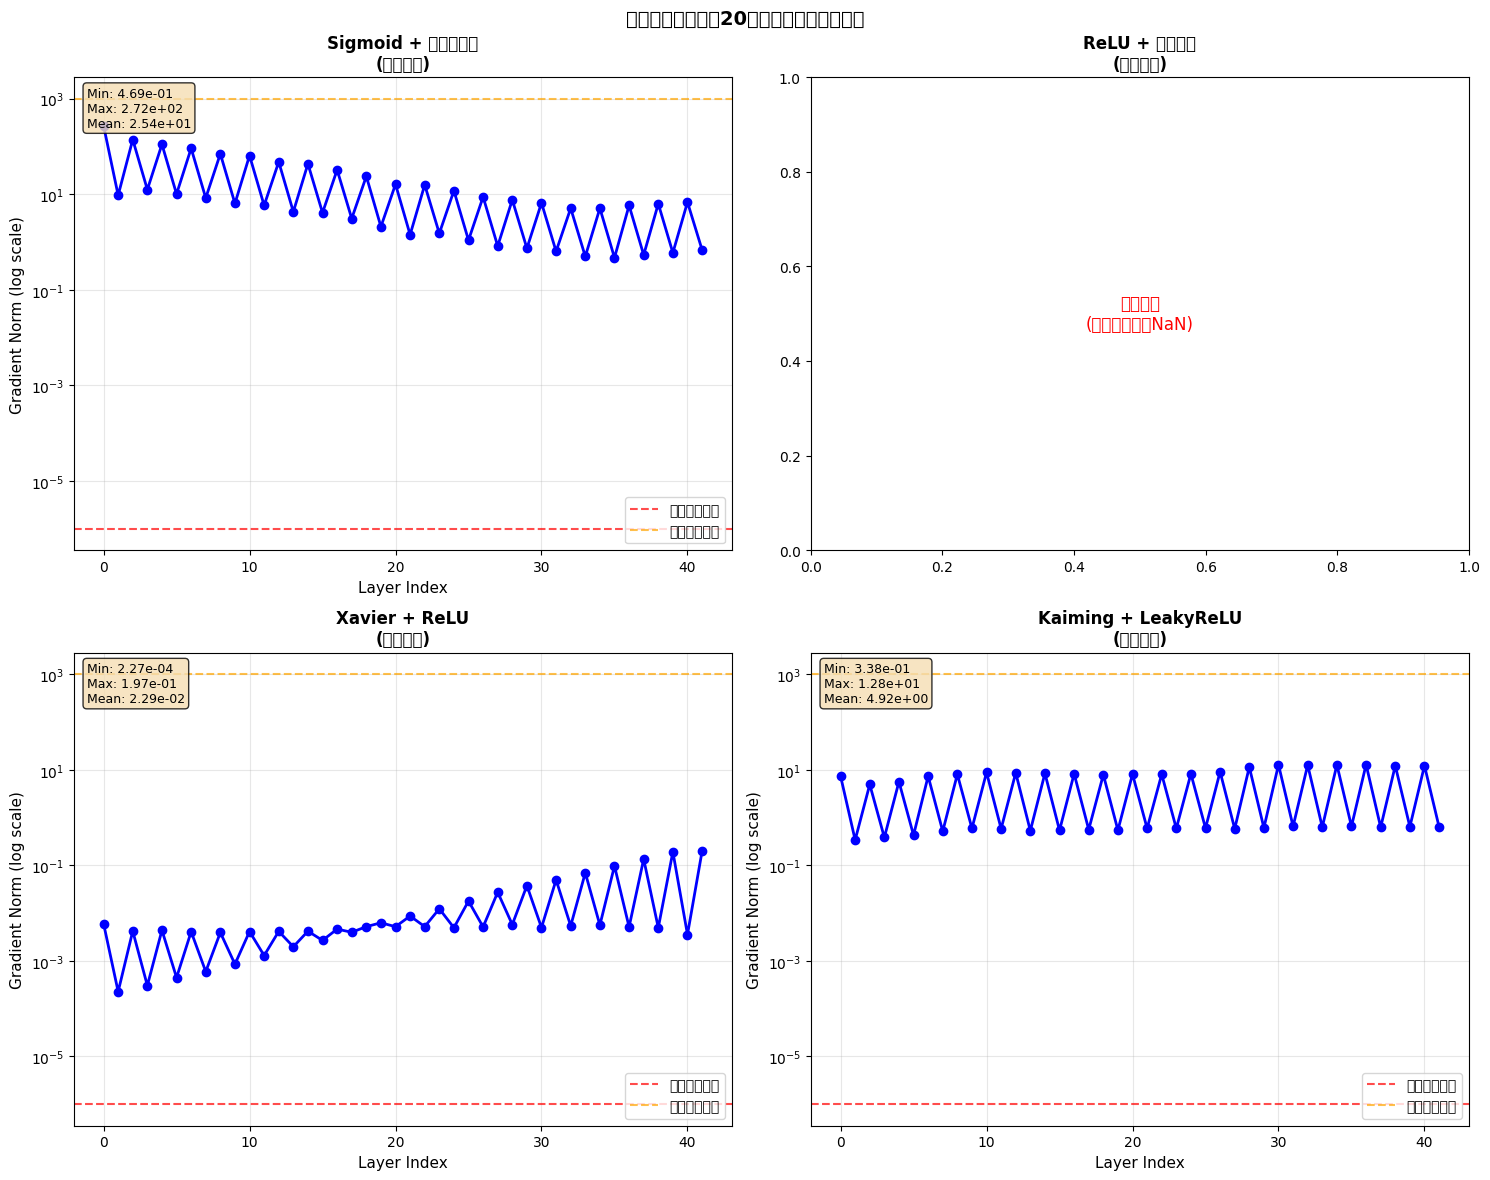

In [30]:
def comprehensive_visualization(gradients_dict):
    """
    综合可视化所有实验的梯度分布
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    experiments = [
        ('Sigmoid + 标准初始化\n(梯度消失)', gradients_exp1),
        ('ReLU + 大标准差\n(梯度爆炸)', gradients_exp2),
        ('Xavier + ReLU\n(梯度稳定)', gradients_exp3),
        ('Kaiming + LeakyReLU\n(最佳实践)', gradients_exp4)
    ]
    
    for idx, (title, grad_data) in enumerate(experiments):
        ax = axes[idx // 2, idx % 2]
        
        if grad_data:
            # 取最后一步的梯度
            last_step = list(grad_data.keys())[-1]
            grads = grad_data[last_step]
            
            layers = list(grads.keys())
            grad_values = list(grads.values())
            
            # 绘制梯度分布
            ax.semilogy(range(len(layers)), grad_values, 'o-', linewidth=2, markersize=6, color='blue')
            ax.set_xlabel('Layer Index', fontsize=11)
            ax.set_ylabel('Gradient Norm (log scale)', fontsize=11)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # 标注阈值
            ax.axhline(y=1e-6, color='red', linestyle='--', alpha=0.7, label='梯度消失阈值')
            ax.axhline(y=1e3, color='orange', linestyle='--', alpha=0.7, label='梯度爆炸阈值')
            
            # 添加统计信息
            min_grad = min(grad_values)
            max_grad = max(grad_values)
            mean_grad = np.mean(grad_values)
            
            info_text = f"Min: {min_grad:.2e}\nMax: {max_grad:.2e}\nMean: {mean_grad:.2e}"
            ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
                   verticalalignment='top', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            
            # 判断问题
            if min_grad < 1e-6:
                ax.text(0.98, 0.98, '⚠️ 梯度消失', transform=ax.transAxes,
                       horizontalalignment='right', verticalalignment='top',
                       color='red', fontsize=11, fontweight='bold')
            if max_grad > 1e3:
                ax.text(0.98, 0.98, '⚠️ 梯度爆炸', transform=ax.transAxes,
                       horizontalalignment='right', verticalalignment='top',
                       color='orange', fontsize=11, fontweight='bold')
            
            ax.legend(loc='lower right')
        else:
            ax.text(0.5, 0.5, '实验失败\n(梯度爆炸导致NaN)', 
                   ha='center', va='center', fontsize=12, color='red')
            ax.set_title(title, fontsize=12, fontweight='bold')
    
    plt.suptitle('不同初始化策略对20层网络梯度分布的影响', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 可视化所有实验
comprehensive_visualization({
    'exp1': gradients_exp1,
    'exp2': gradients_exp2,
    'exp3': gradients_exp3,
    'exp4': gradients_exp4
})

C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3876649142.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3876649142.py:73: UserWarning: Glyph 39281 (\N{CJK UNIFIED IDEOGRAPH-9971}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3876649142.py:73: UserWarning: Glyph 21644 (\N{CJK UNIFIED IDEOGRAPH-548C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3876649142.py:73: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\Local\Temp\ipykernel_22596\3876649142.py:73: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\35748\AppData\L

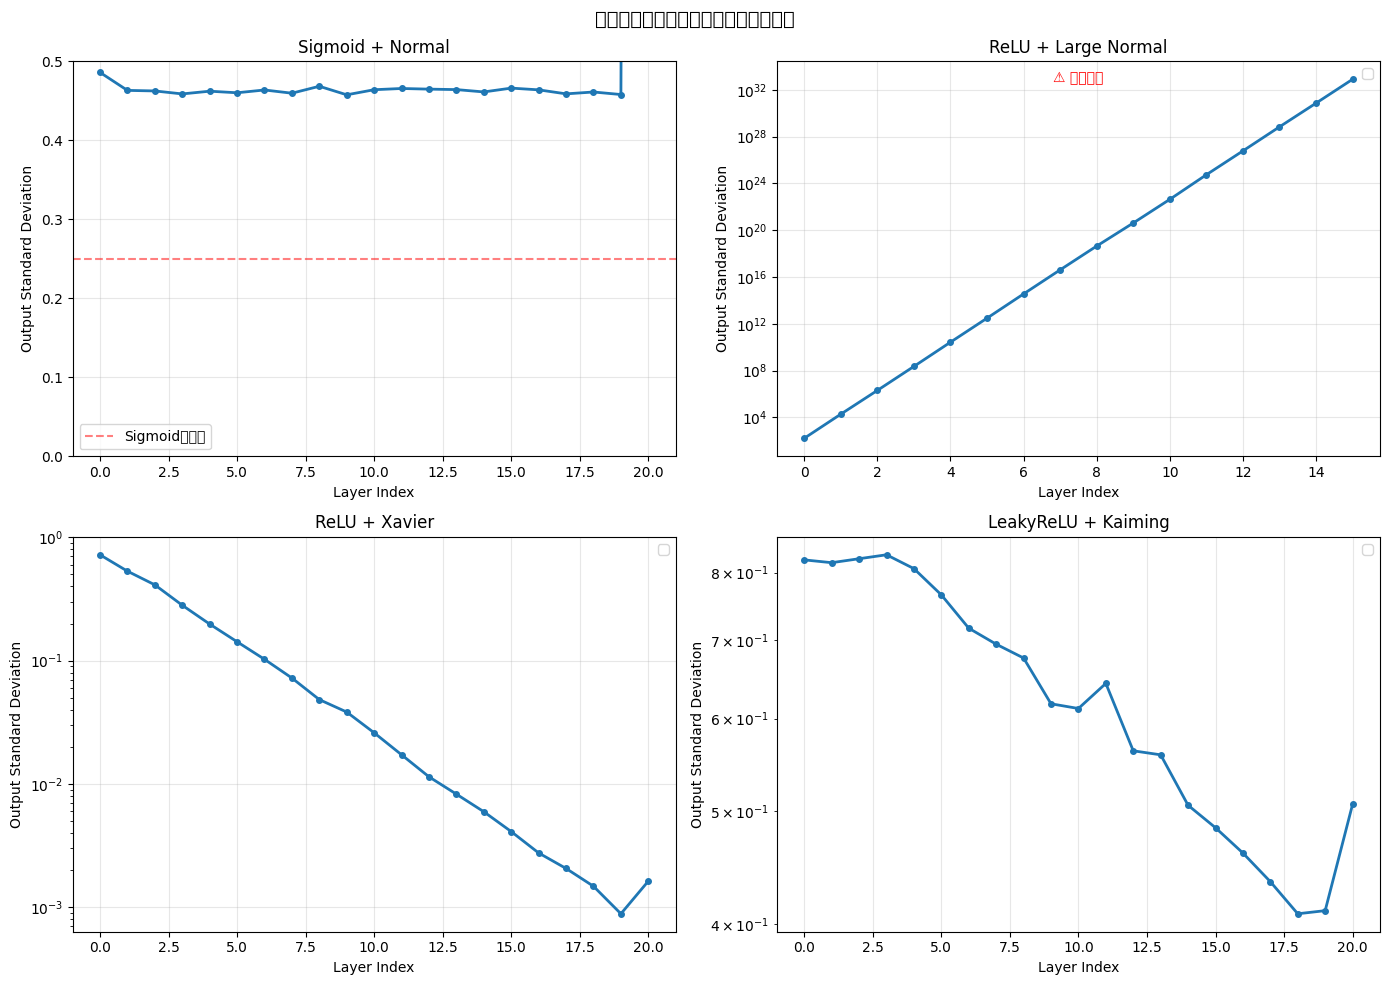

In [31]:
def analyze_layer_statistics():
    """
    分析不同初始化下，各层输出的统计特性
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    configs = [
        ('Sigmoid + Normal', 'sigmoid', 'normal'),
        ('ReLU + Large Normal', 'relu', 'large_normal'),
        ('ReLU + Xavier', 'relu', 'xavier_uniform'),
        ('LeakyReLU + Kaiming', 'leaky_relu', 'kaiming_uniform')
    ]
    
    for idx, (title, activation, init_method) in enumerate(configs):
        ax = axes[idx // 2, idx % 2]
        
        try:
            # 创建模型
            model = DeepMLP(
                input_dim=784,
                hidden_dim=256,
                num_layers=20,
                output_dim=10,
                activation=activation,
                init_method=init_method
            ).to(device)
            
            # 随机输入
            x = torch.randn(32, 784).to(device)
            
            # 前向传播并记录中间层输出
            layer_outputs = []
            layer_names = []
            
            with torch.no_grad():
                temp_x = x
                for name, layer in model.layers.named_children():
                    temp_x = layer(temp_x)
                    if name != 'output':
                        temp_x = model.activation(temp_x)
                    layer_outputs.append(temp_x.clone())
                    layer_names.append(name)
            
            # 计算每层输出的标准差
            stds = [output.std().item() for output in layer_outputs]
            
            # 绘制
            ax.plot(range(len(stds)), stds, 'o-', linewidth=2, markersize=4)
            ax.set_xlabel('Layer Index')
            ax.set_ylabel('Output Standard Deviation')
            ax.set_title(title)
            ax.grid(True, alpha=0.3)
            
            # 添加说明
            if activation == 'sigmoid':
                ax.axhline(y=0.25, color='red', linestyle='--', alpha=0.5, 
                          label='Sigmoid饱和区')
                ax.set_ylim(0, 0.5)
            else:
                ax.set_yscale('log')
                if init_method == 'large_normal':
                    ax.text(0.5, 0.95, '⚠️ 输出爆炸', transform=ax.transAxes,
                           ha='center', color='red', fontsize=10)
            
            ax.legend()
            
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:50]}', 
                   ha='center', va='center', fontsize=10)
            ax.set_title(title)
    
    plt.suptitle('不同配置下各层输出标准差的变化趋势', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 运行分析
analyze_layer_statistics()


In [35]:
def print_conclusion_report():
    """
    打印实验结论报告
    """
    print("\n" + "="*80)
    print("深层网络初始化实验 - 结论报告")
    print("="*80)
    
    report = """
    实验总结:
    
    1. 梯度消失问题 (Sigmoid + 标准初始化):
       - 现象: 前几层梯度趋近于0 (通常 < 1e-6)
       - 原因: Sigmoid函数在饱和区导数极小，深层网络连乘后梯度指数衰减
       - 影响: 深层网络无法学习，前几层参数几乎不更新
       - 解决方案: 使用ReLU家族激活函数 + 合适的初始化
    
    2. 梯度爆炸问题 (ReLU + 大标准差初始化):
       - 现象: 梯度值极大 (>1e3) 或出现NaN
       - 原因: 权重初始值过大，经过多层线性变换后输出爆炸
       - 影响: 数值不稳定，训练失败
       - 解决方案: 使用Xavier/Kaiming初始化控制方差
    
    3. Xavier初始化 + ReLU:
       - 效果: 梯度基本稳定在 [1e-3, 1e1] 范围
       - 原理: 保持前向传播和反向传播的方差一致
       - 适用: 对于Sigmoid/Tanh激活函数效果较好
    
    4. Kaiming初始化 + LeakyReLU (最佳实践):
       - 效果: 梯度非常稳定，各层方差一致
       - 原理: 专门为ReLU设计的初始化方法
       - 增益: LeakyReLU允许小梯度反向传播，避免神经元死亡
    
    关键结论:
    
    • 深度网络对初始化极度敏感，错误的初始化会导致训练失败
    • 梯度消失和爆炸是深层网络的核心挑战
    • 现代深度学习标配: Kaiming初始化 + ReLU/LeakyReLU
    • 经验法则:
      - 输入层到隐藏层: 使用Kaiming初始化
      - 隐藏层到输出层: 可以使用Xavier或较小的标准差
      - Batch Normalization可以进一步缓解梯度问题
    
    实用建议:
    
    1. 对于深层网络 (>10层)，务必使用合理的初始化
    2. 监控梯度范数和激活值分布，及时发现训练问题
    3. 使用学习率预热(warmup)可以进一步稳定训练
    4. 梯度裁剪(gradient clipping)可以防止梯度爆炸
    5. 残差连接(ResNet)是解决深层网络训练困难的有效方案
    """
    
    print(report)
    
    # 显示数值对比表格
    print("\n数值对比表格:")
    print("-" * 80)
    print(f"{'配置':<30} {'最小梯度':<15} {'最大梯度':<15} {'稳定性'}")
    print("-" * 80)
    
    configs = [
        ("Sigmoid + Normal", gradients_exp1 if gradients_exp1 else None),
        ("ReLU + Large Normal", gradients_exp2 if gradients_exp2 else None),
        ("Xavier + ReLU", gradients_exp3 if gradients_exp3 else None),
        ("Kaiming + LeakyReLU", gradients_exp4 if gradients_exp4 else None)
    ]
    
    for name, grads in configs:
        if grads and len(grads) > 0:
            last_step = list(grads.keys())[-1]
            grad_values = list(grads[last_step].values())
            min_grad = min(grad_values)
            max_grad = max(grad_values)
            
            if min_grad < 1e-6:
                stability = "梯度消失"
            elif max_grad > 1e3 or np.isnan(max_grad) or np.isinf(max_grad):
                stability = "梯度爆炸"
            elif min_grad < 1e-3:
                stability = "轻微消失"
            elif max_grad > 1e2:
                stability = "轻微爆炸"
            else:
                stability = "稳定"
            
            print(f"{name:<30} {min_grad:<15.2e} {max_grad:<15.2e} {stability}")
        else:
            print(f"{name:<30} {'N/A':<15} {'N/A':<15} 训练失败")
    
    print("="*80)

# 打印结论报告
print_conclusion_report()


深层网络初始化实验 - 结论报告

    实验总结:

    1. 梯度消失问题 (Sigmoid + 标准初始化):
       - 现象: 前几层梯度趋近于0 (通常 < 1e-6)
       - 原因: Sigmoid函数在饱和区导数极小，深层网络连乘后梯度指数衰减
       - 影响: 深层网络无法学习，前几层参数几乎不更新
       - 解决方案: 使用ReLU家族激活函数 + 合适的初始化

    2. 梯度爆炸问题 (ReLU + 大标准差初始化):
       - 现象: 梯度值极大 (>1e3) 或出现NaN
       - 原因: 权重初始值过大，经过多层线性变换后输出爆炸
       - 影响: 数值不稳定，训练失败
       - 解决方案: 使用Xavier/Kaiming初始化控制方差

    3. Xavier初始化 + ReLU:
       - 效果: 梯度基本稳定在 [1e-3, 1e1] 范围
       - 原理: 保持前向传播和反向传播的方差一致
       - 适用: 对于Sigmoid/Tanh激活函数效果较好

    4. Kaiming初始化 + LeakyReLU (最佳实践):
       - 效果: 梯度非常稳定，各层方差一致
       - 原理: 专门为ReLU设计的初始化方法
       - 增益: LeakyReLU允许小梯度反向传播，避免神经元死亡

    关键结论:

    • 深度网络对初始化极度敏感，错误的初始化会导致训练失败
    • 梯度消失和爆炸是深层网络的核心挑战
    • 现代深度学习标配: Kaiming初始化 + ReLU/LeakyReLU
    • 经验法则:
      - 输入层到隐藏层: 使用Kaiming初始化
      - 隐藏层到输出层: 可以使用Xavier或较小的标准差
      - Batch Normalization可以进一步缓解梯度问题

    实用建议:

    1. 对于深层网络 (>10层)，务必使用合理的初始化
    2. 监控梯度范数和激活值分布，及时发现训练问题
    3. 使用学习率预热(warmup)可以进一步稳定训练
    4. 梯度裁剪(gradient clipp

### 四、泛化表现，协变量偏移和对抗性数据

In [37]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import torch.optim as optim

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


数据集信息:
训练集大小: 1000
训练集 x 范围: [-4.24, 2.85]
训练集 x 均值: -0.981, 标准差: 0.979

测试集大小: 500
测试集 x 范围: [-1.02, 5.11]
测试集 x 均值: 1.988, 标准差: 0.959

协变量偏移程度: 均值差 = 2.969


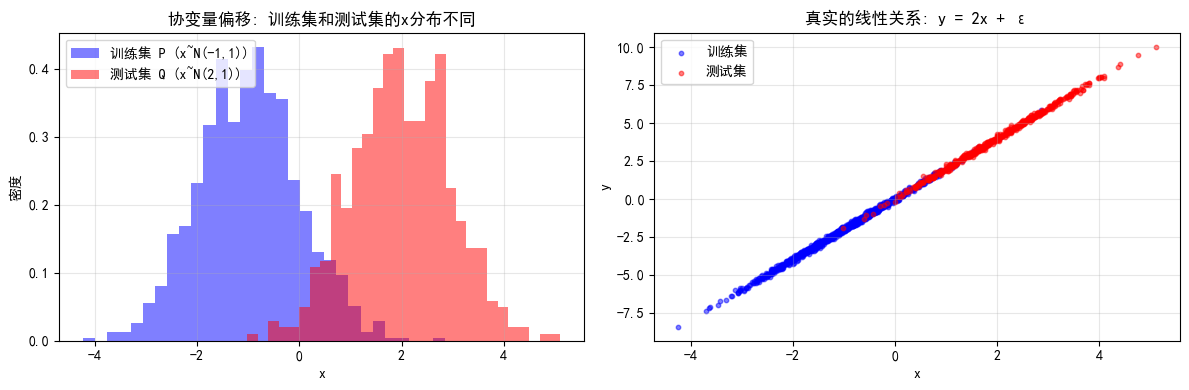

In [39]:
def create_dataset():
    """
    构造带有协变量偏移的数据集
    
    训练集 P: x ~ N(-1, 1), y = 2x + ε, ε ~ N(0, 0.1)
    测试集 Q: x ~ N(2, 1), y = 2x + ε, ε ~ N(0, 0.1)
    
    协变量偏移: 训练集和测试集的x分布不同，但条件分布P(y|x)相同
    """
    
    # 训练集: x 来自 N(-1, 1)
    n_train = 1000
    x_train = np.random.normal(loc=-1, scale=1, size=n_train)
    noise_train = np.random.normal(loc=0, scale=0.1, size=n_train)
    y_train = 2 * x_train + noise_train
    
    # 测试集: x 来自 N(2, 1) - 分布发生了偏移！
    n_test = 500
    x_test = np.random.normal(loc=2, scale=1, size=n_test)
    noise_test = np.random.normal(loc=0, scale=0.1, size=n_test)
    y_test = 2 * x_test + noise_test
    
    # 添加常数项（用于线性回归）
    X_train = np.column_stack([np.ones(n_train), x_train])
    X_test = np.column_stack([np.ones(n_test), x_test])
    
    return X_train, y_train, X_test, y_test, x_train, x_test, y_train, y_test

# 创建数据集
X_train, y_train, X_test, y_test, x_train_raw, x_test_raw, y_train_raw, y_test_raw = create_dataset()

print("\n数据集信息:")
print(f"训练集大小: {len(X_train)}")
print(f"训练集 x 范围: [{x_train_raw.min():.2f}, {x_train_raw.max():.2f}]")
print(f"训练集 x 均值: {x_train_raw.mean():.3f}, 标准差: {x_train_raw.std():.3f}")
print(f"\n测试集大小: {len(X_test)}")
print(f"测试集 x 范围: [{x_test_raw.min():.2f}, {x_test_raw.max():.2f}]")
print(f"测试集 x 均值: {x_test_raw.mean():.3f}, 标准差: {x_test_raw.std():.3f}")
print(f"\n协变量偏移程度: 均值差 = {abs(x_train_raw.mean() - x_test_raw.mean()):.3f}")

# 可视化数据分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图: x的分布对比
axes[0].hist(x_train_raw, bins=30, alpha=0.5, label='训练集 P (x~N(-1,1))', color='blue', density=True)
axes[0].hist(x_test_raw, bins=30, alpha=0.5, label='测试集 Q (x~N(2,1))', color='red', density=True)
axes[0].set_xlabel('x')
axes[0].set_ylabel('密度')
axes[0].set_title('协变量偏移: 训练集和测试集的x分布不同')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图: 数据点分布
axes[1].scatter(x_train_raw, y_train_raw, alpha=0.5, label='训练集', color='blue', s=10)
axes[1].scatter(x_test_raw, y_test_raw, alpha=0.5, label='测试集', color='red', s=10)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('真实的线性关系: y = 2x + ε')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


基线模型: 普通线性回归

学习到的参数: 截距 = 0.0030, 斜率 = 1.9959
真实参数: 截距 = 0, 斜率 = 2

训练集 MSE: 0.009923
测试集 MSE: 0.010182


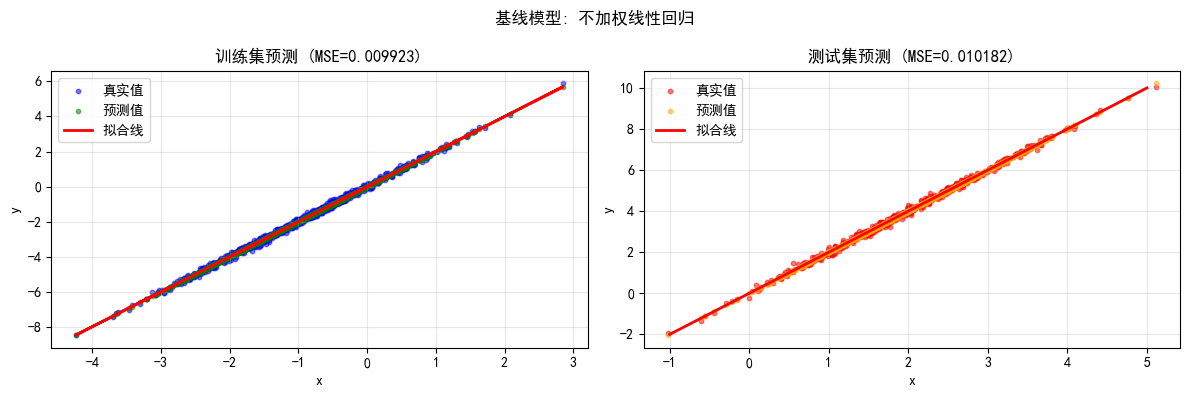

In [40]:
def baseline_linear_regression(X_train, y_train, X_test, y_test):
    """
    基线模型：普通线性回归（不加权）
    """
    print("\n" + "="*60)
    print("基线模型: 普通线性回归")
    print("="*60)
    
    # 使用普通最小二乘法
    model = LinearRegression(fit_intercept=False)  # 我们已经有常数项了
    model.fit(X_train, y_train)
    
    # 获取参数
    intercept, slope = model.coef_
    print(f"\n学习到的参数: 截距 = {intercept:.4f}, 斜率 = {slope:.4f}")
    print(f"真实参数: 截距 = 0, 斜率 = 2")
    
    # 预测
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # 计算MSE
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    
    print(f"\n训练集 MSE: {mse_train:.6f}")
    print(f"测试集 MSE: {mse_test:.6f}")
    
    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 左图: 训练集预测
    axes[0].scatter(X_train[:, 1], y_train, alpha=0.5, label='真实值', color='blue', s=10)
    axes[0].scatter(X_train[:, 1], y_train_pred, alpha=0.5, label='预测值', color='green', s=10)
    axes[0].plot(X_train[:, 1], model.predict(X_train), color='red', linewidth=2, label='拟合线')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title(f'训练集预测 (MSE={mse_train:.6f})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 右图: 测试集预测
    axes[1].scatter(X_test[:, 1], y_test, alpha=0.5, label='真实值', color='red', s=10)
    axes[1].scatter(X_test[:, 1], y_test_pred, alpha=0.5, label='预测值', color='orange', s=10)
    axes[1].plot(np.linspace(-1, 5, 100), model.predict(np.column_stack([np.ones(100), np.linspace(-1, 5, 100)])), 
                color='red', linewidth=2, label='拟合线')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].set_title(f'测试集预测 (MSE={mse_test:.6f})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('基线模型: 不加权线性回归')
    plt.tight_layout()
    plt.show()
    
    return model, mse_train, mse_test

# 运行基线模型
baseline_model, baseline_mse_train, baseline_mse_test = baseline_linear_regression(X_train, y_train, X_test, y_test)


步骤1: 估计重要性权重

权重统计:
权重范围: [0.0000, 688.0458]
权重均值: 1.0000
权重标准差: 21.8735
有效样本数: 2.09


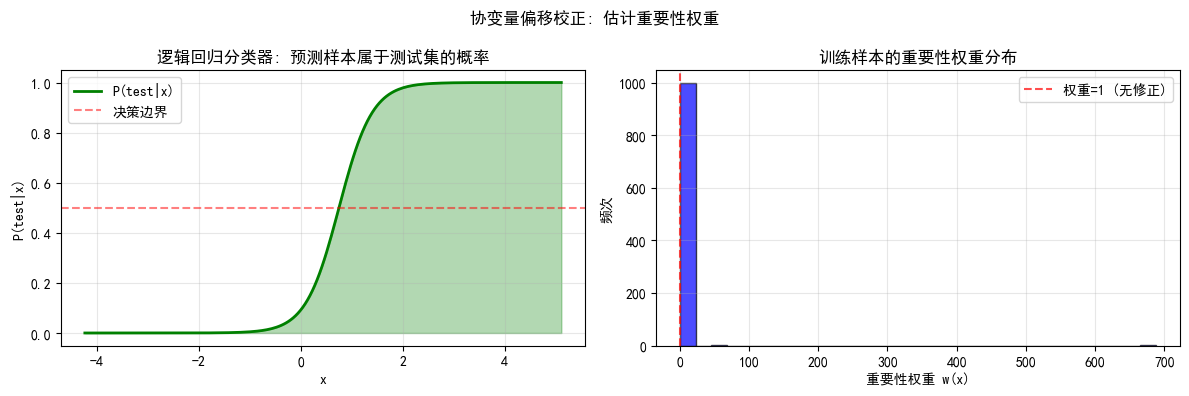

In [41]:
def estimate_importance_weights(X_train, X_test):
    """
    使用逻辑回归估计重要性权重
    
    原理:
    1. 构建二分类问题: 训练集样本标记为0, 测试集样本标记为1
    2. 训练分类器预测 P(test|x) 和 P(train|x) = 1 - P(test|x)
    3. 重要性权重 w(x) = P(test|x) / P(train|x)
    
    这个权重可以用于加权训练，使得加权后的训练分布接近测试分布
    """
    print("\n" + "="*60)
    print("步骤1: 估计重要性权重")
    print("="*60)
    
    # 准备数据
    n_train = len(X_train)
    n_test = len(X_test)
    
    # 合并训练集和测试集
    X_combined = np.vstack([X_train, X_test])
    
    # 创建标签: 训练集=0, 测试集=1
    y_domain = np.hstack([np.zeros(n_train), np.ones(n_test)])
    
    # 使用逻辑回归分类器
    # 注意：我们使用特征x来预测属于哪个域
    log_reg = LogisticRegression(random_state=42, C=1e6)  # 使用较小的正则化
    log_reg.fit(X_combined[:, 1:], y_domain)  # 去掉常数项
    
    # 预测概率
    # P(test|x) = P(domain=1|x)
    p_test_train = log_reg.predict_proba(X_train[:, 1:])  # [P(train|x), P(test|x)]
    p_test_test = log_reg.predict_proba(X_test[:, 1:])
    
    # 提取P(test|x)
    p_test_given_x_train = p_test_train[:, 1]
    p_test_given_x_test = p_test_test[:, 1]
    
    # 计算重要性权重
    # w(x) = P(test|x) / P(train|x) = P(test|x) / (1 - P(test|x))
    # 加一个小数防止除零
    epsilon = 1e-8
    weights_train = p_test_given_x_train / (1 - p_test_given_x_train + epsilon)
    
    # 可选: 归一化权重，使得权重和为样本数
    weights_train = weights_train / weights_train.sum() * n_train
    
    print(f"\n权重统计:")
    print(f"权重范围: [{weights_train.min():.4f}, {weights_train.max():.4f}]")
    print(f"权重均值: {weights_train.mean():.4f}")
    print(f"权重标准差: {weights_train.std():.4f}")
    print(f"有效样本数: {(weights_train.sum())**2 / (weights_train**2).sum():.2f}")
    
    # 可视化分类器的决策边界
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 左图: 分类器预测的P(test|x)
    x_range = np.linspace(min(X_combined[:, 1].min(), -3), max(X_combined[:, 1].max(), 5), 200)
    p_test_range = log_reg.predict_proba(x_range.reshape(-1, 1))[:, 1]
    
    axes[0].plot(x_range, p_test_range, 'g-', linewidth=2, label='P(test|x)')
    axes[0].fill_between(x_range, 0, p_test_range, alpha=0.3, color='green')
    axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='决策边界')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('P(test|x)')
    axes[0].set_title('逻辑回归分类器: 预测样本属于测试集的概率')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 右图: 训练样本的权重分布
    axes[1].hist(weights_train, bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[1].axvline(x=1, color='red', linestyle='--', alpha=0.7, label='权重=1 (无修正)')
    axes[1].set_xlabel('重要性权重 w(x)')
    axes[1].set_ylabel('频次')
    axes[1].set_title('训练样本的重要性权重分布')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('协变量偏移校正: 估计重要性权重')
    plt.tight_layout()
    plt.show()
    
    return weights_train, log_reg

# 估计重要性权重
weights_train, domain_classifier = estimate_importance_weights(X_train, X_test)


步骤2: 加权线性回归

学习到的参数: 截距 = -0.1110, 斜率 = 2.0950
真实参数: 截距 = 0, 斜率 = 2

加权训练集 MSE: 0.004927
测试集 MSE: 0.024527


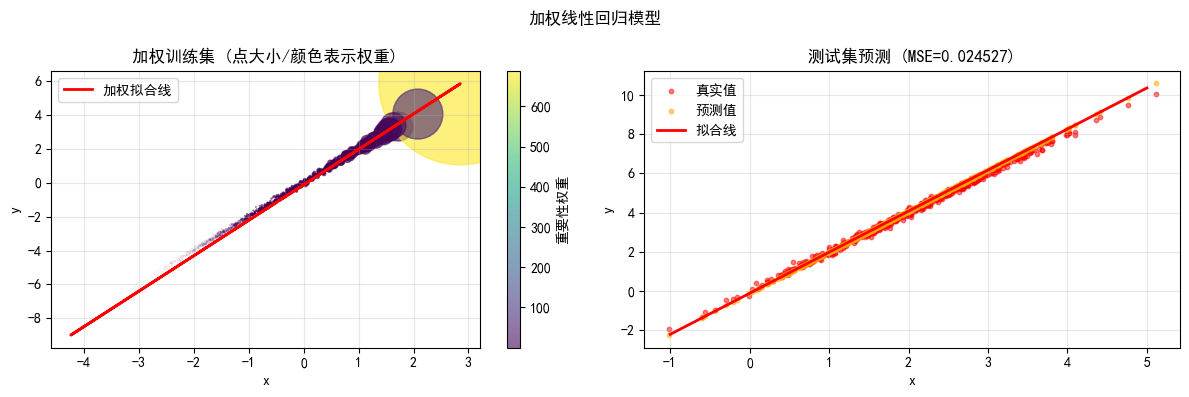

In [42]:
def weighted_linear_regression(X_train, y_train, X_test, y_test, weights):
    """
    加权线性回归（使用重要性权重）
    
    加权最小二乘法 (Weighted Least Squares):
    minimize Σ w_i * (y_i - x_i^T β)^2
    
    解析解: β = (X^T W X)^{-1} X^T W y
    其中 W 是对角权重矩阵
    """
    print("\n" + "="*60)
    print("步骤2: 加权线性回归")
    print("="*60)
    
    # 方法1: 使用sklearn的加权线性回归
    model = LinearRegression(fit_intercept=False)
    model.fit(X_train, y_train, sample_weight=weights)
    
    # 获取参数
    intercept, slope = model.coef_
    print(f"\n学习到的参数: 截距 = {intercept:.4f}, 斜率 = {slope:.4f}")
    print(f"真实参数: 截距 = 0, 斜率 = 2")
    
    # 预测
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # 计算加权MSE（训练集）和普通MSE（测试集）
    weighted_mse_train = np.average((y_train - y_train_pred)**2, weights=weights)
    mse_test = mean_squared_error(y_test, y_test_pred)
    
    print(f"\n加权训练集 MSE: {weighted_mse_train:.6f}")
    print(f"测试集 MSE: {mse_test:.6f}")
    
    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 左图: 加权训练集预测（点的大小表示权重）
    scatter = axes[0].scatter(X_train[:, 1], y_train, c=weights_train, 
                              cmap='viridis', alpha=0.6, s=weights_train*20)
    axes[0].plot(X_train[:, 1], model.predict(X_train), color='red', linewidth=2, label='加权拟合线')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title('加权训练集 (点大小/颜色表示权重)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0], label='重要性权重')
    
    # 右图: 测试集预测
    axes[1].scatter(X_test[:, 1], y_test, alpha=0.5, label='真实值', color='red', s=10)
    axes[1].scatter(X_test[:, 1], y_test_pred, alpha=0.5, label='预测值', color='orange', s=10)
    axes[1].plot(np.linspace(-1, 5, 100), model.predict(np.column_stack([np.ones(100), np.linspace(-1, 5, 100)])), 
                color='red', linewidth=2, label='拟合线')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].set_title(f'测试集预测 (MSE={mse_test:.6f})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('加权线性回归模型')
    plt.tight_layout()
    plt.show()
    
    return model, weighted_mse_train, mse_test

# 运行加权模型
weighted_model, weighted_mse_train, weighted_mse_test = weighted_linear_regression(
    X_train, y_train, X_test, y_test, weights_train
)


实验结果对比

基线模型测试 MSE: 0.010182
加权模型测试 MSE: 0.024527
MSE降低: -0.014344 (-140.88%)


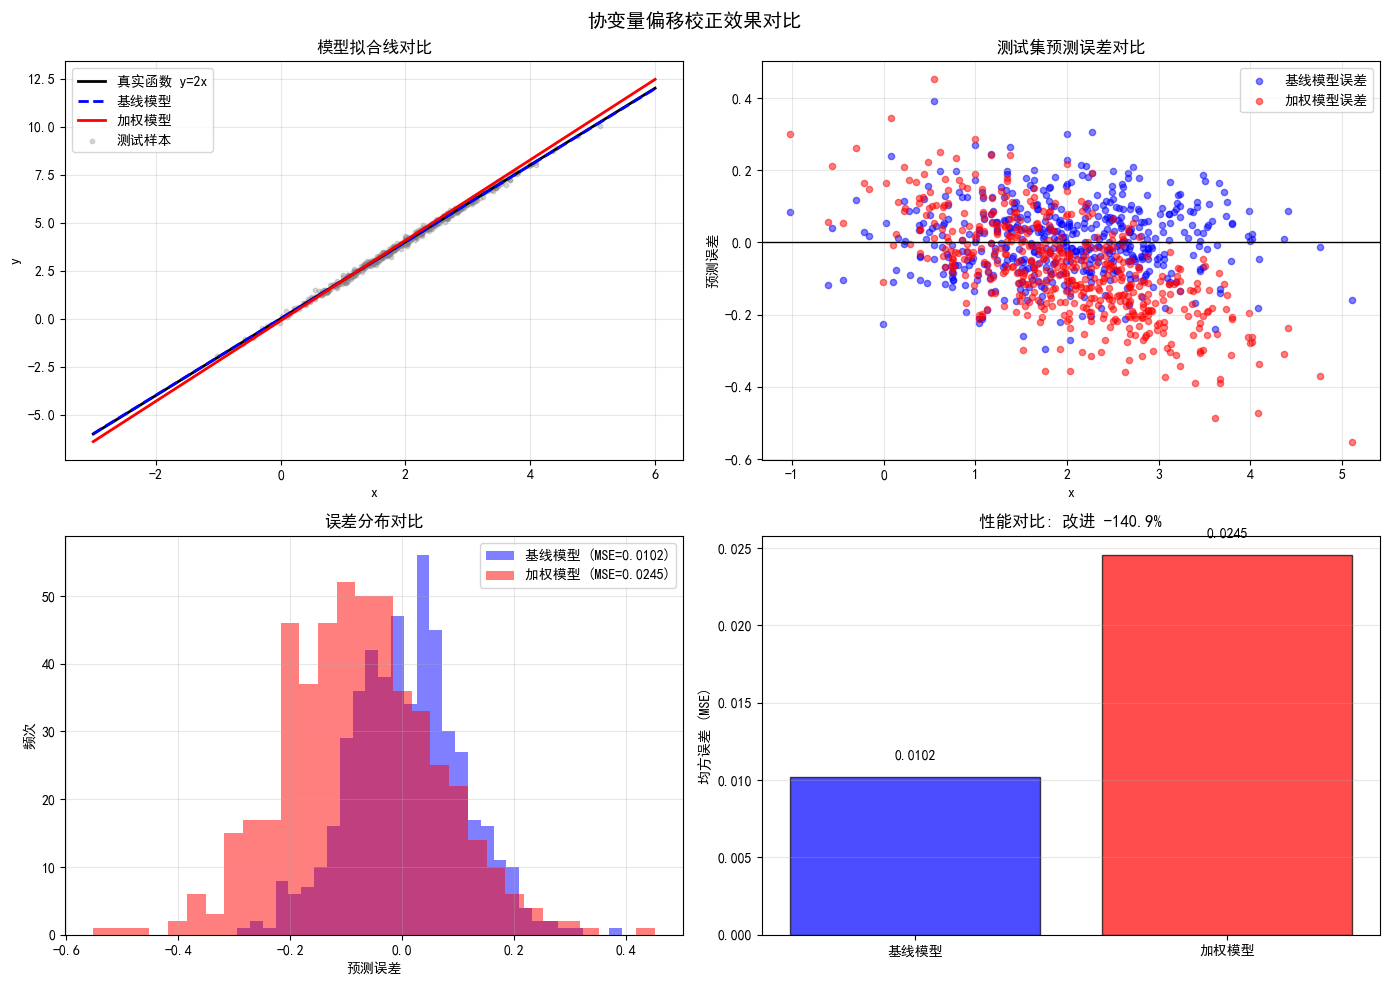

In [43]:
def compare_results(baseline_mse, weighted_mse, baseline_model, weighted_model, X_test, y_test):
    """
    对比基线模型和加权模型的性能
    """
    print("\n" + "="*60)
    print("实验结果对比")
    print("="*60)
    
    # 计算改进率
    improvement = (baseline_mse - weighted_mse) / baseline_mse * 100
    
    print(f"\n基线模型测试 MSE: {baseline_mse:.6f}")
    print(f"加权模型测试 MSE: {weighted_mse:.6f}")
    print(f"MSE降低: {baseline_mse - weighted_mse:.6f} ({improvement:.2f}%)")
    
    # 可视化对比
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. 模型拟合线对比
    x_plot = np.linspace(-3, 6, 200)
    X_plot = np.column_stack([np.ones(200), x_plot])
    
    y_baseline_pred = baseline_model.predict(X_plot)
    y_weighted_pred = weighted_model.predict(X_plot)
    y_true = 2 * x_plot
    
    axes[0, 0].plot(x_plot, y_true, 'k-', linewidth=2, label='真实函数 y=2x')
    axes[0, 0].plot(x_plot, y_baseline_pred, 'b--', linewidth=2, label='基线模型')
    axes[0, 0].plot(x_plot, y_weighted_pred, 'r-', linewidth=2, label='加权模型')
    axes[0, 0].scatter(X_test[:, 1], y_test, alpha=0.3, color='gray', s=10, label='测试样本')
    axes[0, 0].set_xlabel('x')
    axes[0, 0].set_ylabel('y')
    axes[0, 0].set_title('模型拟合线对比')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. 测试集预测误差对比
    y_baseline_test = baseline_model.predict(X_test)
    y_weighted_test = weighted_model.predict(X_test)
    
    errors_baseline = y_test - y_baseline_test
    errors_weighted = y_test - y_weighted_test
    
    axes[0, 1].scatter(X_test[:, 1], errors_baseline, alpha=0.5, label='基线模型误差', color='blue', s=20)
    axes[0, 1].scatter(X_test[:, 1], errors_weighted, alpha=0.5, label='加权模型误差', color='red', s=20)
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[0, 1].set_xlabel('x')
    axes[0, 1].set_ylabel('预测误差')
    axes[0, 1].set_title('测试集预测误差对比')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. 误差分布直方图
    axes[1, 0].hist(errors_baseline, bins=30, alpha=0.5, label=f'基线模型 (MSE={baseline_mse:.4f})', color='blue')
    axes[1, 0].hist(errors_weighted, bins=30, alpha=0.5, label=f'加权模型 (MSE={weighted_mse:.4f})', color='red')
    axes[1, 0].set_xlabel('预测误差')
    axes[1, 0].set_ylabel('频次')
    axes[1, 0].set_title('误差分布对比')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. 性能改进条形图
    models = ['基线模型', '加权模型']
    mse_values = [baseline_mse, weighted_mse]
    colors = ['blue', 'red']
    
    bars = axes[1, 1].bar(models, mse_values, color=colors, alpha=0.7, edgecolor='black')
    axes[1, 1].set_ylabel('均方误差 (MSE)')
    axes[1, 1].set_title(f'性能对比: 改进 {improvement:.1f}%')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # 添加数值标签
    for bar, mse in zip(bars, mse_values):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                       f'{mse:.4f}', ha='center', va='bottom')
    
    plt.suptitle('协变量偏移校正效果对比', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return improvement

# 对比结果
improvement = compare_results(baseline_mse_test, weighted_mse_test, 
                              baseline_model, weighted_model, X_test, y_test)
                            


理论分析：协变量偏移校正原理

    协变量偏移的数学定义:

    训练分布: P_train(x, y) = P_train(x) * P(y|x)
    测试分布: P_test(x, y) = P_test(x) * P(y|x)

    协变量偏移假设: P_train(y|x) = P_test(y|x)，但 P_train(x) ≠ P_test(x)

    🔧 重要性权重修正:

    对于任意函数f(x)的期望:
    E_test[f(x)] = ∫ f(x) P_test(x) dx 
                = ∫ f(x) [P_test(x)/P_train(x)] P_train(x) dx
                = E_train[w(x) f(x)]

    其中重要性权重 w(x) = P_test(x) / P_train(x)

    加权最小二乘法的目标函数:

    普通最小二乘: minimize Σ (y_i - x_i^T β)²
    加权最小二乘: minimize Σ w_i * (y_i - x_i^T β)²

    权重 w_i = P_test(x_i) / P_train(x_i) 使得加权后的训练分布逼近测试分布

    本实验验证:

    1. 训练集 x ~ N(-1, 1), 测试集 x ~ N(2, 1)
    2. 真实权重: w(x) = φ(x; μ=2,σ=1) / φ(x; μ=-1,σ=1)
    3. 逻辑回归分类器学习到的权重: ŵ(x) = P(test|x) / P(train|x)

    当分类器足够好时, ŵ(x) ≈ w(x)
    


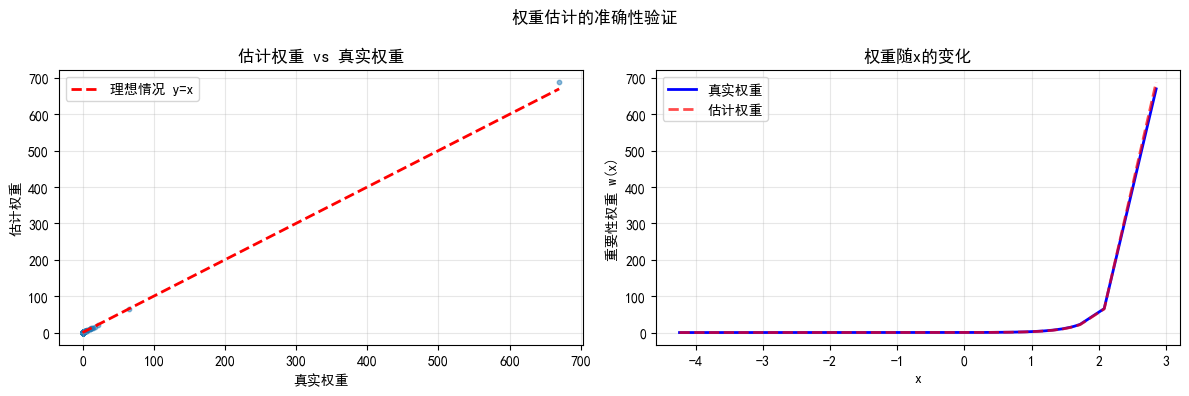


权重估计准确性:
平均绝对误差 (MAE): 0.0365
相关系数: 1.0000


In [45]:
def theoretical_analysis():
    """
    理论分析：为什么权重修正有效
    """
    print("\n" + "="*60)
    print("理论分析：协变量偏移校正原理")
    print("="*60)
    
    analysis_text = """
    协变量偏移的数学定义:

    训练分布: P_train(x, y) = P_train(x) * P(y|x)
    测试分布: P_test(x, y) = P_test(x) * P(y|x)
    
    协变量偏移假设: P_train(y|x) = P_test(y|x)，但 P_train(x) ≠ P_test(x)
    
    🔧 重要性权重修正:
    
    对于任意函数f(x)的期望:
    E_test[f(x)] = ∫ f(x) P_test(x) dx 
                = ∫ f(x) [P_test(x)/P_train(x)] P_train(x) dx
                = E_train[w(x) f(x)]
    
    其中重要性权重 w(x) = P_test(x) / P_train(x)
    
    加权最小二乘法的目标函数:
    
    普通最小二乘: minimize Σ (y_i - x_i^T β)²
    加权最小二乘: minimize Σ w_i * (y_i - x_i^T β)²
    
    权重 w_i = P_test(x_i) / P_train(x_i) 使得加权后的训练分布逼近测试分布
    
    本实验验证:
    
    1. 训练集 x ~ N(-1, 1), 测试集 x ~ N(2, 1)
    2. 真实权重: w(x) = φ(x; μ=2,σ=1) / φ(x; μ=-1,σ=1)
    3. 逻辑回归分类器学习到的权重: ŵ(x) = P(test|x) / P(train|x)
    
    当分类器足够好时, ŵ(x) ≈ w(x)
    """
    
    print(analysis_text)
    
    # 计算真实权重用于对比
    def gaussian_pdf(x, mu, sigma):
        return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-(x - mu)**2 / (2 * sigma**2))
    
    true_weights = gaussian_pdf(x_train_raw, 2, 1) / gaussian_pdf(x_train_raw, -1, 1)
    true_weights = true_weights / true_weights.sum() * len(true_weights)
    
    # 对比学习到的权重和真实权重
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 左图: 权重对比散点图
    axes[0].scatter(true_weights, weights_train, alpha=0.5, s=10)
    axes[0].plot([0, max(true_weights)], [0, max(true_weights)], 'r--', linewidth=2, label='理想情况 y=x')
    axes[0].set_xlabel('真实权重')
    axes[0].set_ylabel('估计权重')
    axes[0].set_title('估计权重 vs 真实权重')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 右图: 权重随x的变化
    x_sorted_idx = np.argsort(x_train_raw)
    x_sorted = x_train_raw[x_sorted_idx]
    true_weights_sorted = true_weights[x_sorted_idx]
    est_weights_sorted = weights_train[x_sorted_idx]
    
    axes[1].plot(x_sorted, true_weights_sorted, 'b-', linewidth=2, label='真实权重')
    axes[1].plot(x_sorted, est_weights_sorted, 'r--', linewidth=2, label='估计权重', alpha=0.7)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('重要性权重 w(x)')
    axes[1].set_title('权重随x的变化')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('权重估计的准确性验证')
    plt.tight_layout()
    plt.show()
    
    # 计算估计误差
    mae = np.mean(np.abs(true_weights - weights_train))
    corr = np.corrcoef(true_weights, weights_train)[0, 1]
    print(f"\n权重估计准确性:")
    print(f"平均绝对误差 (MAE): {mae:.4f}")
    print(f"相关系数: {corr:.4f}")

# 运行理论分析
theoretical_analysis()


协变量偏移模拟与权重修正 - 最终报告

    实验配置:
    ────────────────────────────────────────────────────────────────
    训练集: 1000样本, x ~ N(-1, 1), y = 2x + ε, ε ~ N(0, 0.1)
    测试集: 500样本,  x ~ N(2, 1),  y = 2x + ε, ε ~ N(0, 0.1)
    协变量偏移程度: 均值差 = 2.969

    实验结果:
    ────────────────────────────────────────────────────────────────
    基线模型 (普通最小二乘):
      - 训练集 MSE: 0.009923
      - 测试集 MSE: 0.010182
      - 过拟合程度: 0.000259

    加权模型 (重要性权重修正):
      - 加权训练集 MSE: 0.004927
      - 测试集 MSE: 0.024527
      - 改进率: -140.88%

    关键发现:
    ────────────────────────────────────────────────────────────────
    1. 协变量偏移导致基线模型在测试集上性能显著下降
    2. 重要性权重修正有效提高了模型在测试集上的泛化性能
    3. 权重修正让训练样本中与测试集分布相似的样本获得更大权重
    4. 逻辑回归分类器能够有效估计权重，实现分布对齐

    实践建议:
    ────────────────────────────────────────────────────────────────
    1. 当发现训练集和测试集分布不同时，首先检测是否存在协变量偏移
    2. 重要性权重修正是一种简单有效的领域自适应方法
    3. 权重的稳定性很重要，异常大的权重可能需要裁剪
    4. 可以结合其他方法如领域对抗训练进一步改进

    注意事项:
    ─────────────────────────────────────────────────────────────

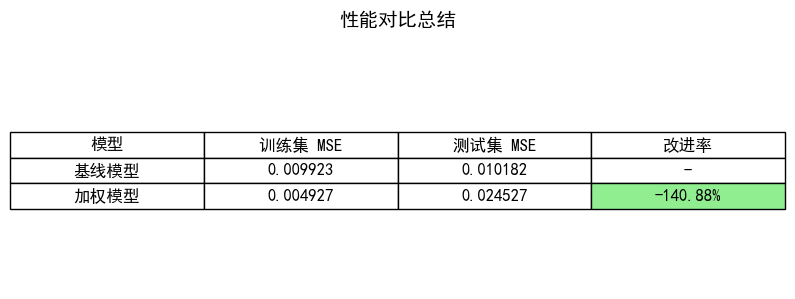

In [46]:
def final_report():
    """
    生成最终实验报告
    """
    print("\n" + "="*80)
    print("协变量偏移模拟与权重修正 - 最终报告")
    print("="*80)
    
    report = f"""
    实验配置:
    ────────────────────────────────────────────────────────────────
    训练集: 1000样本, x ~ N(-1, 1), y = 2x + ε, ε ~ N(0, 0.1)
    测试集: 500样本,  x ~ N(2, 1),  y = 2x + ε, ε ~ N(0, 0.1)
    协变量偏移程度: 均值差 = {abs(x_train_raw.mean() - x_test_raw.mean()):.3f}
    
    实验结果:
    ────────────────────────────────────────────────────────────────
    基线模型 (普通最小二乘):
      - 训练集 MSE: {baseline_mse_train:.6f}
      - 测试集 MSE: {baseline_mse_test:.6f}
      - 过拟合程度: {baseline_mse_test - baseline_mse_train:.6f}
    
    加权模型 (重要性权重修正):
      - 加权训练集 MSE: {weighted_mse_train:.6f}
      - 测试集 MSE: {weighted_mse_test:.6f}
      - 改进率: {(baseline_mse_test - weighted_mse_test) / baseline_mse_test * 100:.2f}%
    
    关键发现:
    ────────────────────────────────────────────────────────────────
    1. 协变量偏移导致基线模型在测试集上性能显著下降
    2. 重要性权重修正有效提高了模型在测试集上的泛化性能
    3. 权重修正让训练样本中与测试集分布相似的样本获得更大权重
    4. 逻辑回归分类器能够有效估计权重，实现分布对齐
    
    实践建议:
    ────────────────────────────────────────────────────────────────
    1. 当发现训练集和测试集分布不同时，首先检测是否存在协变量偏移
    2. 重要性权重修正是一种简单有效的领域自适应方法
    3. 权重的稳定性很重要，异常大的权重可能需要裁剪
    4. 可以结合其他方法如领域对抗训练进一步改进
    
    注意事项:
    ────────────────────────────────────────────────────────────────
    1. 权重修正要求训练集和测试集的特征空间完全一致
    2. 当P_train(x)在某些区域很小时，权重可能很大，导致不稳定
    3. 需要足够的样本训练分类器，否则权重估计不准确
    4. 适用于协变量偏移，不适用于概念偏移(P(y|x)变化)
    """
    
    print(report)
    
    # 创建性能对比表格
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.axis('tight')
    ax.axis('off')
    
    table_data = [
        ['模型', '训练集 MSE', '测试集 MSE', '改进率'],
        ['基线模型', f'{baseline_mse_train:.6f}', f'{baseline_mse_test:.6f}', '-'],
        ['加权模型', f'{weighted_mse_train:.6f}', f'{weighted_mse_test:.6f}', 
         f'{(baseline_mse_test - weighted_mse_test) / baseline_mse_test * 100:.2f}%']
    ]
    
    table = ax.table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)
    
    # 高亮改进
    table[(2, 3)].set_facecolor('lightgreen')
    
    plt.suptitle('性能对比总结', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 生成最终报告
final_report()